In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, UpSampling2D, TimeDistributed, SimpleRNN, GRU, LSTM, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from skimage.feature import hog
from skimage.color import rgb2gray
import warnings
warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = cifar10.load_data()
X_full = np.concatenate((X_train_orig, X_test_orig), axis=0)
y_full = np.concatenate((y_train_orig, y_test_orig), axis=0).flatten()
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print("Loaded CIFAR-10 dataset")
print("Full dataset shape:", X_full.shape)
print("Unique labels:", np.unique(y_full))
print("Class count:")
print(pd.Series(y_full).value_counts().sort_index())

sample_size = 12000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_full), sample_size, replace=False)
X = X_full[sample_idx]
y = y_full[sample_idx]

print("Using sample size:", X.shape)

Loaded CIFAR-10 dataset
Full dataset shape: (60000, 32, 32, 3)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Class count:
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64
Using sample size: (12000, 32, 32, 3)


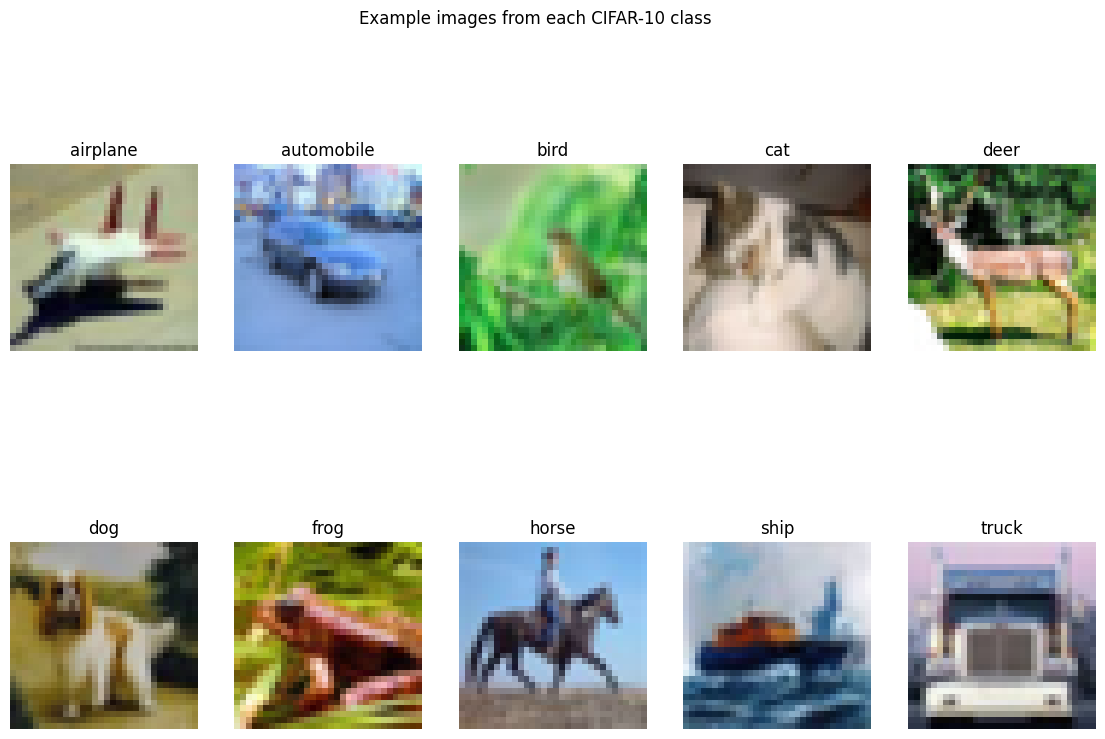

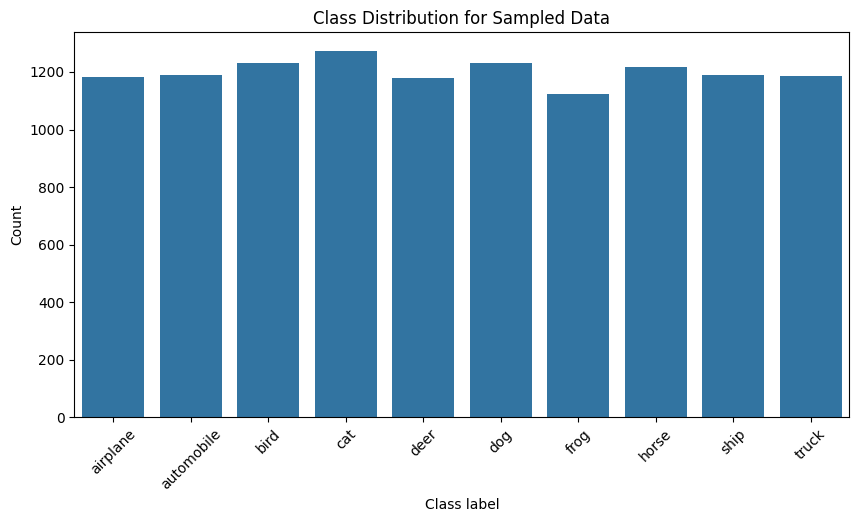

Pixel value range: 0.0 1.0
Per-channel mean: [0.4922244 0.481917  0.4455828]
Per-channel std: [0.2472198  0.24374154 0.26133972]


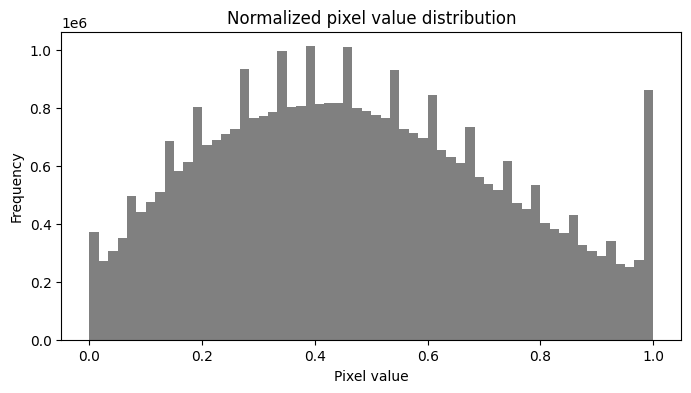

In [4]:
plt.figure(figsize=(14, 9))
for i in range(10):
    idx = np.where(y == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx])
    plt.title(classes[i])
    plt.axis('off')
plt.suptitle('Example images from each CIFAR-10 class')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x=y)
plt.title('Class Distribution for Sampled Data')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.xticks(ticks=np.arange(10), labels=classes, rotation=45)
plt.show()

X_norm = X.astype('float32') / 255.0
print('Pixel value range:', X_norm.min(), X_norm.max())
print('Per-channel mean:', X_norm.mean(axis=(0,1,2)))
print('Per-channel std:', X_norm.std(axis=(0,1,2)))

plt.figure(figsize=(8, 4))
plt.hist(X_norm.ravel(), bins=60, color='gray')
plt.title('Normalized pixel value distribution')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.show()

In [5]:
def extract_hog_features(images, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    features = []
    for img in images:
        gray = rgb2gray(img)
        features.append(hog(gray, pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, feature_vector=True))
    return np.array(features)

X_hog = extract_hog_features(X)
print('HOG feature shape:', X_hog.shape)

scaler = StandardScaler()
X_hog_scaled = scaler.fit_transform(X_hog)

X_train, X_test, y_train, y_test = train_test_split(X_hog_scaled, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

HOG feature shape: (12000, 324)
Train shape: (9600, 324) Test shape: (2400, 324)


In [6]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
print('Best KNN params:', knn_grid.best_params_)

nb_grid = GridSearchCV(GaussianNB(), {'var_smoothing': [1e-9, 1e-8, 1e-7]}, cv=3, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train, y_train)
print('Best NB params:', nb_grid.best_params_)

knn_best = knn_grid.best_estimator_
nb_best = nb_grid.best_estimator_

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

ada = AdaBoostClassifier(n_estimators=80, random_state=42)
ada.fit(X_train, y_train)

voting = VotingClassifier(estimators=[('knn', knn_best), ('rf', rf), ('ada', ada)], voting='soft')
voting.fit(X_train, y_train)

Best KNN params: {'n_neighbors': 7, 'weights': 'distance'}
Best NB params: {'var_smoothing': 1e-09}


VotingClassifier(estimators=[('knn',
                              KNeighborsClassifier(n_neighbors=7,
                                                   weights='distance')),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('ada',
                              AdaBoostClassifier(n_estimators=80,
                                                 random_state=42))],
                 voting='soft')

In [7]:
models = [
    ('KNN', knn_best),
    ('Naive Bayes', nb_best),
    ('Random Forest', rf),
    ('AdaBoost', ada),
    ('Voting', voting)
]

results = []
for name, model in models:
    y_pred = model.predict(X_test)
    results.append((name,
                    accuracy_score(y_test, y_pred),
                    f1_score(y_test, y_pred, average='weighted')))

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Weighted F1'])
print(results_df)

best_model_name, best_accuracy, _ = results[0]
for name, acc, _ in results:
    if acc > best_accuracy:
        best_model_name = name
        best_accuracy = acc

print(f"Best classical model: {best_model_name} (accuracy={best_accuracy:.4f})")

           Model  Accuracy  Weighted F1
0            KNN  0.435833     0.436231
1    Naive Bayes  0.448333     0.443022
2  Random Forest  0.463750     0.461775
3       AdaBoost  0.297917     0.296832
4         Voting  0.476250     0.476389
Best classical model: Voting (accuracy=0.4763)


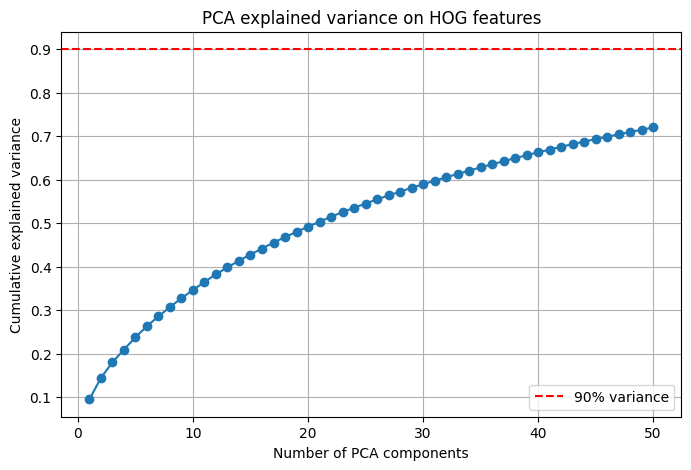

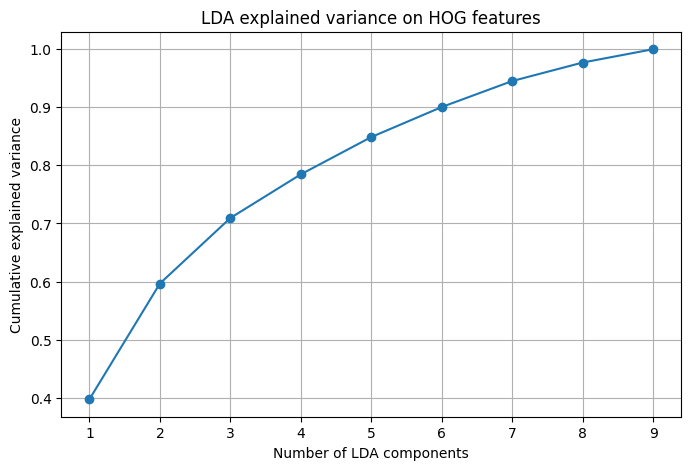

In [8]:
pca = PCA(n_components=50, random_state=42)
pca.fit(X_train)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance on HOG features')
plt.grid(True)
plt.axhline(0.90, linestyle='--', color='red', label='90% variance')
plt.legend()
plt.show()

lda = LDA(n_components=9)
lda.fit(X_train, y_train)
lda_explained = np.cumsum(lda.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(lda_explained)+1), lda_explained, marker='o')
plt.xlabel('Number of LDA components')
plt.ylabel('Cumulative explained variance')
plt.title('LDA explained variance on HOG features')
plt.grid(True)
plt.show()

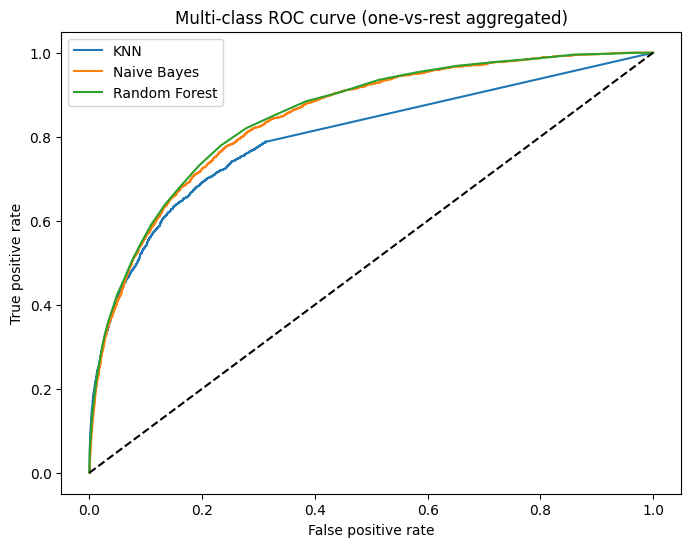

Classification report for best model: Voting
              precision    recall  f1-score   support

    airplane       0.70      0.44      0.54       236
  automobile       0.69      0.60      0.64       238
        bird       0.55      0.30      0.39       246
         cat       0.47      0.19      0.27       255
        deer       0.28      0.52      0.36       236
         dog       0.44      0.38      0.41       246
        frog       0.33      0.74      0.46       225
       horse       0.66      0.45      0.54       243
        ship       0.60      0.61      0.61       238
       truck       0.57      0.58      0.57       237

    accuracy                           0.48      2400
   macro avg       0.53      0.48      0.48      2400
weighted avg       0.53      0.48      0.48      2400



In [9]:
y_test_bin = label_binarize(y_test, classes=np.arange(10))
plt.figure(figsize=(8, 6))
for model, label in [(knn_best, 'KNN'), (nb_best, 'Naive Bayes'), (rf, 'Random Forest')]:
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multi-class ROC curve (one-vs-rest aggregated)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()

print('Classification report for best model:', best_model_name)
print(classification_report(y_test, voting.predict(X_test), target_names=classes))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,170 (2.26 MB)

 Trainable params: 591,722 (2.26 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
319/319 - 22s - 70ms/step - accuracy: 0.4478 - loss: 1.5665 - val_accuracy: 0.1560 - val_loss: 3.2931
Epoch 2/10
319/319 - 4s - 12ms/step - accuracy: 0.6138 - loss: 1.0914 - val_accuracy: 0.6081 - val_loss: 1.1385
Epoch 3/10
319/319 - 4s - 13ms/step - accuracy: 0.6747 - loss: 0.9312 - val_accuracy: 0.6954 - val_loss: 0.8721
Epoch 4/10
319/319 - 4s - 12ms/step - accuracy: 0.7041 - loss: 0.8462 - val_accuracy: 0.6440 - val_loss: 1.0560
Epoch 5/10
319/319 - 4s - 12ms/step - accuracy: 0.7283 - loss: 0.7781 - val_accuracy: 0.7212 - val_loss: 0.7806
Epoch 6/10
319/319 - 4s - 13ms/step - accuracy: 0.7468 - loss: 0.7255 - val_accuracy: 0.7360 - val_loss: 0.7513
Epoch 7/10
319/319 - 4s - 12ms/step - accuracy: 0.7622 - loss: 0.6794 - val_accuracy: 0.7333 - val_loss: 0.7656
Epoch 8/10
319/319 - 4s - 12ms/step - accuracy: 0.7757 - loss: 0.6422 - val_accuracy: 0.7729 - val_loss: 0.6501
Epoch 9/10
319/319 - 4s - 13ms/step - accuracy: 0.7857 - loss: 0.6114 - val_accuracy: 0.7765 - val_loss

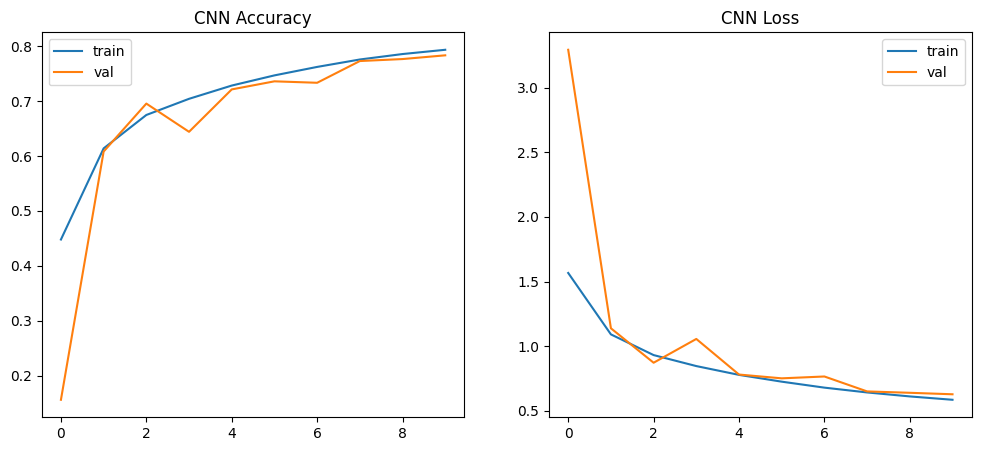

CNN test loss/accuracy: [0.6522764563560486, 0.7761666774749756]


In [10]:
# Phase 2: CNN and Transfer Learning
X_dl = X_full.astype('float32') / 255.0
y_dl = to_categorical(y_full, num_classes=10)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, stratify=y_full, random_state=42)

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train_dl, y_train_dl,
    validation_split=0.15,
    epochs=10,
    batch_size=128,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=2
)

train_acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
train_loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='train')
plt.plot(val_acc, label='val')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.title('CNN Loss')
plt.legend()
plt.show()

cnn_eval = model_cnn.evaluate(X_test_dl, y_test_dl, verbose=0)
print('CNN test loss/accuracy:', cnn_eval)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,299 (262.89 KB)

 Trainable params: 67,299 (262.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
319/319 - 11s - 35ms/step - loss: 0.0133 - val_loss: 0.0084
Epoch 2/8
319/319 - 3s - 11ms/step - loss: 0.0078 - val_loss: 0.0072
Epoch 3/8
319/319 - 4s - 11ms/step - loss: 0.0071 - val_loss: 0.0067
Epoch 4/8
319/319 - 4s - 12ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 5/8
319/319 - 4s - 11ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 6/8
319/319 - 4s - 11ms/step - loss: 0.0061 - val_loss: 0.0062
Epoch 7/8
319/319 - 4s - 11ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 8/8
319/319 - 4s - 12ms/step - loss: 0.0058 - val_loss: 0.0056
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step


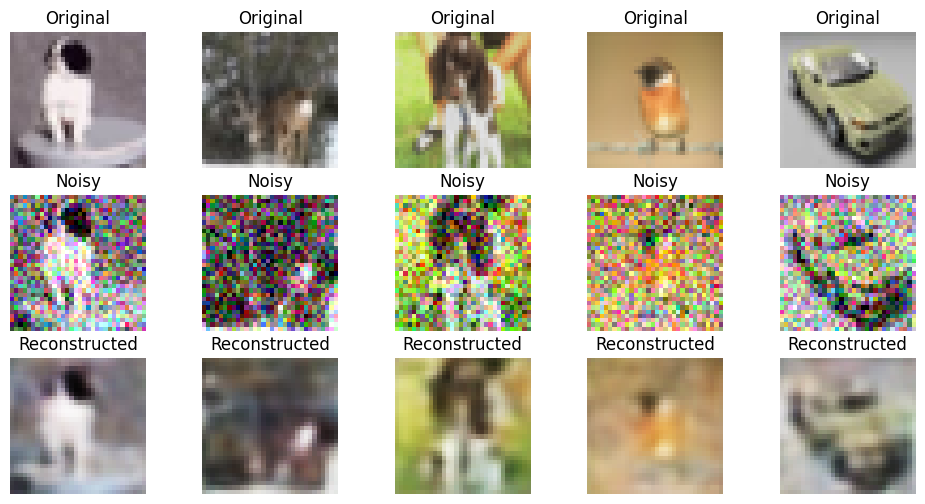

In [11]:
# Phase 2: Autoencoder for image reconstruction
noise_factor = 0.2
X_train_noisy = np.clip(X_train_dl + noise_factor * np.random.normal(size=X_train_dl.shape), 0., 1.)
X_test_noisy = np.clip(X_test_dl + noise_factor * np.random.normal(size=X_test_dl.shape), 0., 1.)

input_img = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

autoencoder.fit(X_train_noisy, X_train_dl,
                epochs=8,
                batch_size=128,
                shuffle=True,
                validation_split=0.15,
                verbose=2)

reconstructed = autoencoder.predict(X_test_noisy[:10])
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_dl[i])
    plt.title('Original')
    plt.axis('off')
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test_noisy[i])
    plt.title('Noisy')
    plt.axis('off')
    plt.subplot(3, 5, i + 11)
    plt.imshow(reconstructed[i])
    plt.title('Reconstructed')
    plt.axis('off')
plt.show()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,106 (9.99 MB)

 Trainable params: 362,122 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Phase 1: Training classification head (base frozen) ---
Epoch 1/5
638/638 - 51s - 80ms/step - accuracy: 0.7425 - loss: 0.7799 - val_accuracy: 0.8486 - val_loss: 0.4558 - learning_rate: 0.0010
Epoch 2/5
638/638 - 10s - 15ms/step - accuracy: 0.8232 - loss: 0.5361 - val_accuracy: 0.8535 - val_loss: 0.4373 - learning_rate: 0.0010
Epoch 3/5
638/638 - 10s - 15ms/step - accuracy: 0.8403 - loss: 0.4802 - val_accuracy: 0.8604 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 4/5
638/638 - 10s - 15ms/step - accuracy: 0.8507 - loss: 0.4481 - val_accuracy: 0.8676 - val_loss: 0.3907 - learning_rate: 0.0010
Epoch 5/5
638/638 - 10s - 15ms/step - accuracy: 0.8592 - loss: 0.4207 - val_accuracy: 0.8636 - val_loss: 0.3922 - learning_rate: 0.0010

--- Phase 2: Fine-tuning last 20 layers ---
Epoch 1/5
638/638 - 45s - 70ms/step - accuracy: 0.8460 - loss: 0.4811 - val_accuracy: 0.8579 - val_loss: 0.4323 - learning_rate: 1.0000e-04
Epoch 2/5
638/638 - 11s - 18ms/step - accuracy: 0.9026 - loss: 0.3004 - va

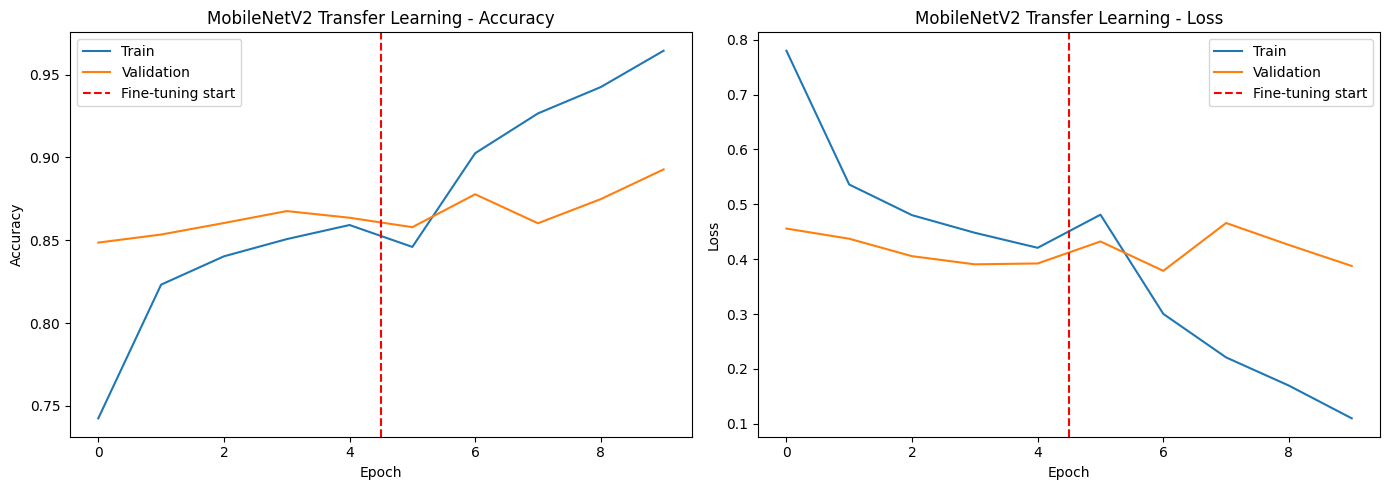

375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step

MobileNetV2 Transfer Learning Classification Report:
              precision    recall  f1-score   support

    airplane       0.90      0.90      0.90      1200
  automobile       0.89      0.96      0.92      1200
        bird       0.94      0.79      0.86      1200
         cat       0.77      0.77      0.77      1200
        deer       0.70      0.94      0.80      1200
         dog       0.88      0.76      0.82      1200
        frog       0.87      0.95      0.91      1200
       horse       0.95      0.82      0.88      1200
        ship       0.93      0.94      0.93      1200
       truck       0.96      0.89      0.93      1200

    accuracy                           0.87     12000
   macro avg       0.88      0.87      0.87     12000
weighted avg       0.88      0.87      0.87     12000



In [12]:
# ============================================================
# PHASE 2 : Transfer Learning with MobileNetV2
# ============================================================
# Copy this into a new notebook cell after the AutoEncoder cell

# --- Transfer Learning: Fine-tune MobileNetV2 ---
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                     Dropout, Input, Resizing)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Use existing X_train_dl, X_test_dl, y_train_dl, y_test_dl (32x32 images)
# We embed a Resizing layer INSIDE the model to avoid large memory allocation.

# Build MobileNetV2 base (expects min 32x32, we'll upscale to 96x96 inside model)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze the base model layers initially
base_model.trainable = False

# Build model with resizing inside the pipeline
inputs = Input(shape=(32, 32, 3))
x = Resizing(96, 96)(inputs)                       # upscale 32->96 inside model
x = tf.keras.layers.Lambda(
        lambda img: preprocess_input(img * 255.0)   # MobileNetV2 expects [0,255]
    )(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model_tl = Model(inputs, outputs)

# Compile
model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

# Callbacks
early_stop_tl = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# Phase 1: Train with frozen base (feature extraction)
print("\n--- Phase 1: Training classification head (base frozen) ---")
history_tl_phase1 = model_tl.fit(
    X_train_dl, y_train_dl,          # pass 32x32 images directly
    validation_split=0.15,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=2
)

# Phase 2: Fine-tune – unfreeze last 20 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 2: Fine-tuning last 20 layers ---")
history_tl_phase2 = model_tl.fit(
    X_train_dl, y_train_dl,          # pass 32x32 images directly
    validation_split=0.15,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=2
)

# Evaluate
tl_eval = model_tl.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f'\nMobileNetV2 Transfer Learning - Test Loss: {tl_eval[0]:.4f}, '
      f'Test Accuracy: {tl_eval[1]:.4f}')

# Plot training curves for fine-tuning phase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine histories
acc = history_tl_phase1.history['accuracy'] + history_tl_phase2.history['accuracy']
val_acc = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']
loss = history_tl_phase1.history['loss'] + history_tl_phase2.history['loss']
val_loss = history_tl_phase1.history['val_loss'] + history_tl_phase2.history['val_loss']

# Accuracy
axes[0].plot(acc, label='Train')
axes[0].plot(val_acc, label='Validation')
axes[0].axvline(x=len(history_tl_phase1.history['accuracy'])-0.5,
                color='r', linestyle='--', label='Fine-tuning start')
axes[0].set_title('MobileNetV2 Transfer Learning - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(loss, label='Train')
axes[1].plot(val_loss, label='Validation')
axes[1].axvline(x=len(history_tl_phase1.history['loss'])-0.5,
                color='r', linestyle='--', label='Fine-tuning start')
axes[1].set_title('MobileNetV2 Transfer Learning - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
y_pred_tl = model_tl.predict(X_test_dl)
y_pred_tl_classes = np.argmax(y_pred_tl, axis=1)
y_true_classes = np.argmax(y_test_dl, axis=1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nMobileNetV2 Transfer Learning Classification Report:")
print(classification_report(y_true_classes, y_pred_tl_classes,
                            target_names=class_names))



Training with: Adam (lr=0.001)
Epoch 1/10
319/319 - 16s - 50ms/step - accuracy: 0.4293 - loss: 1.6735 - val_accuracy: 0.2064 - val_loss: 2.7378 - learning_rate: 0.0010
Epoch 2/10
319/319 - 4s - 12ms/step - accuracy: 0.5886 - loss: 1.1658 - val_accuracy: 0.6329 - val_loss: 1.0386 - learning_rate: 0.0010
Epoch 3/10
319/319 - 4s - 12ms/step - accuracy: 0.6537 - loss: 0.9955 - val_accuracy: 0.6042 - val_loss: 1.1773 - learning_rate: 0.0010
Epoch 4/10

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
319/319 - 4s - 12ms/step - accuracy: 0.6876 - loss: 0.9014 - val_accuracy: 0.6199 - val_loss: 1.0810 - learning_rate: 0.0010
Epoch 5/10
319/319 - 4s - 12ms/step - accuracy: 0.7230 - loss: 0.8044 - val_accuracy: 0.7407 - val_loss: 0.7388 - learning_rate: 5.0000e-04
Epoch 6/10
319/319 - 4s - 12ms/step - accuracy: 0.7354 - loss: 0.7655 - val_accuracy: 0.7565 - val_loss: 0.6885 - learning_rate: 5.0000e-04
Epoch 7/10
319/319 - 4s - 12ms/step - accuracy: 0.7515 - loss: 0.7

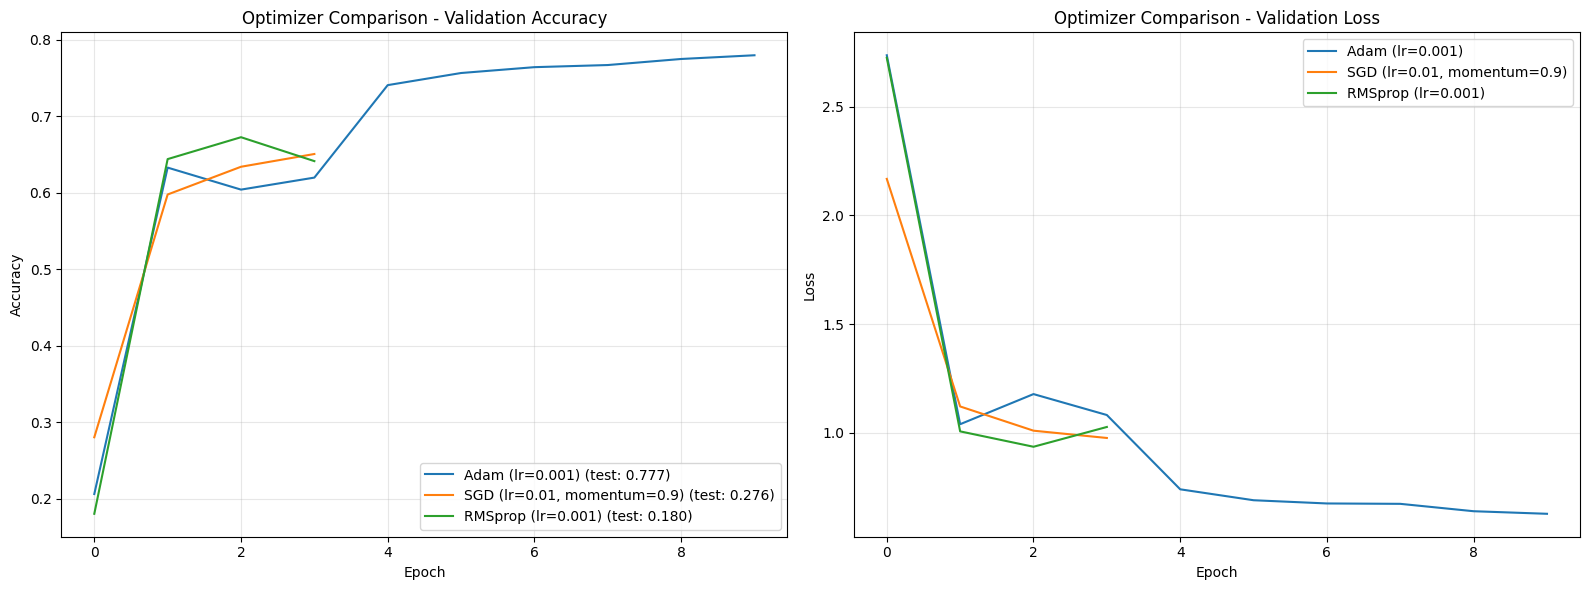


OPTIMIZER COMPARISON SUMMARY
Optimizer                             Test Acc  Test Loss
------------------------------------------------------------
Adam (lr=0.001)                         0.7768     0.6372
SGD (lr=0.01, momentum=0.9)             0.2758     2.1585
RMSprop (lr=0.001)                      0.1804     2.7167


In [13]:
# ============================================================
# PHASE 2 : Compare Optimizers & LR Schedulers
# ============================================================

# --- Optimizer & Learning Rate Scheduler Comparison ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

def build_cnn_model():
    """Build identical CNN model for fair comparison."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

# Define optimizers to compare
optimizers = {
    'Adam (lr=0.001)': Adam(learning_rate=0.001),
    'SGD (lr=0.01, momentum=0.9)': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop (lr=0.001)': RMSprop(learning_rate=0.001),
}

# ReduceLROnPlateau scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

results = {}

for name, optimizer in optimizers.items():
    print(f"\n{'='*60}")
    print(f"Training with: {name}")
    print(f"{'='*60}")

    model = build_cnn_model()
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_dl, y_train_dl,
        validation_split=0.15,
        epochs=10,
        batch_size=128,
        callbacks=[early_stop, reduce_lr],
        verbose=2
    )

    test_loss, test_acc = model.evaluate(X_test_dl, y_test_dl, verbose=0)
    results[name] = {
        'history': history,
        'test_loss': test_loss,
        'test_acc': test_acc
    }
    print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    h = res['history']
    axes[0].plot(h.history['val_accuracy'], label=f'{name} (test: {res["test_acc"]:.3f})')
    axes[1].plot(h.history['val_loss'], label=name)

axes[0].set_title('Optimizer Comparison - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Optimizer Comparison - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*60)
print("OPTIMIZER COMPARISON SUMMARY")
print("="*60)
print(f"{'Optimizer':<35} {'Test Acc':>10} {'Test Loss':>10}")
print("-"*60)
for name, res in results.items():
    print(f"{name:<35} {res['test_acc']:>10.4f} {res['test_loss']:>10.4f}")
print("="*60)

Convolutional layers found: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3']


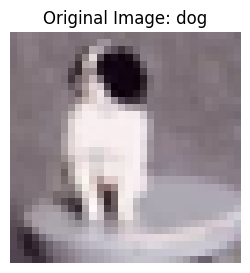

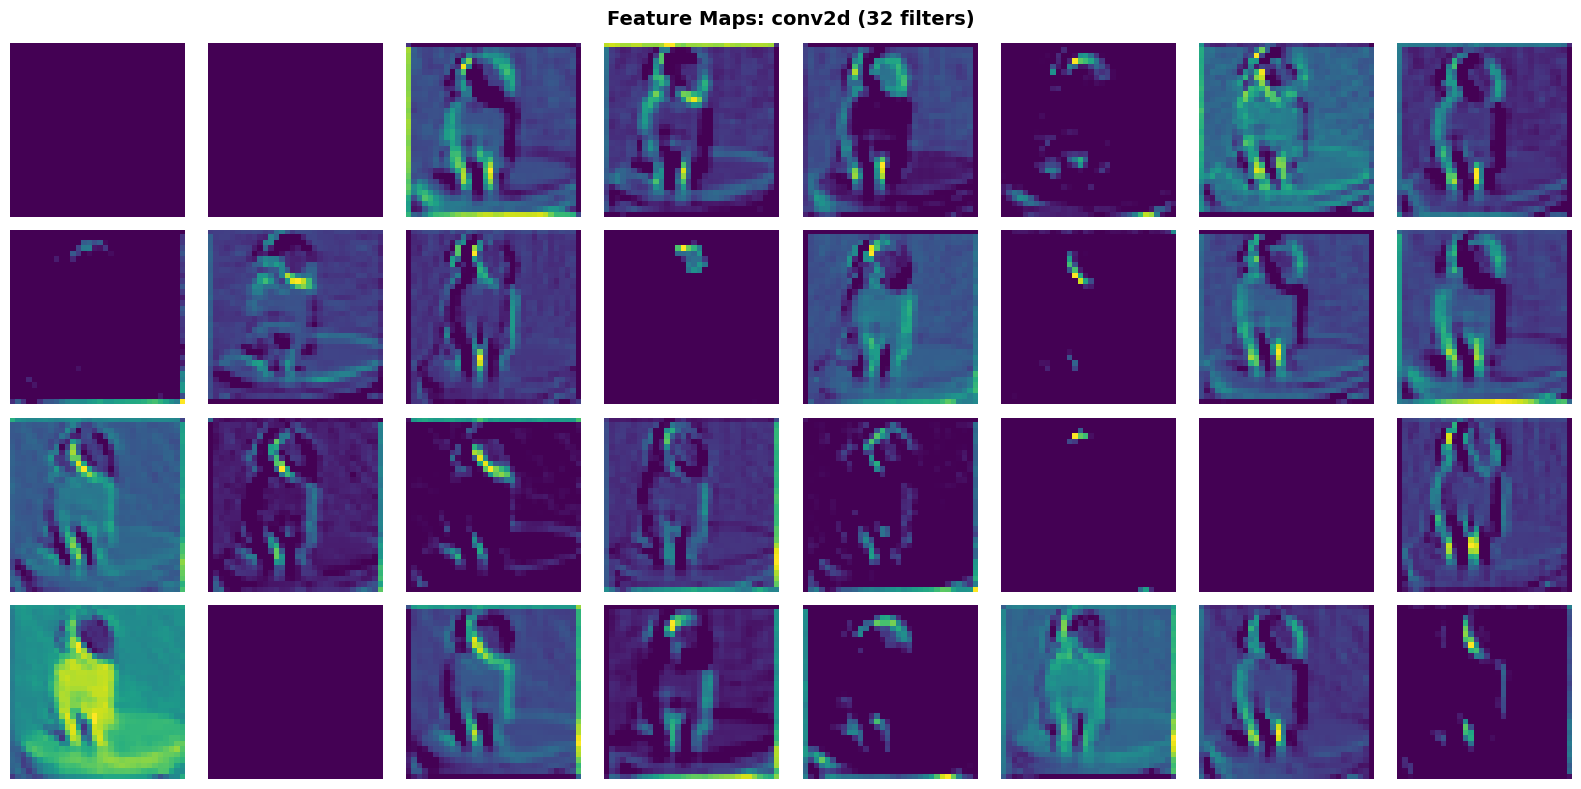

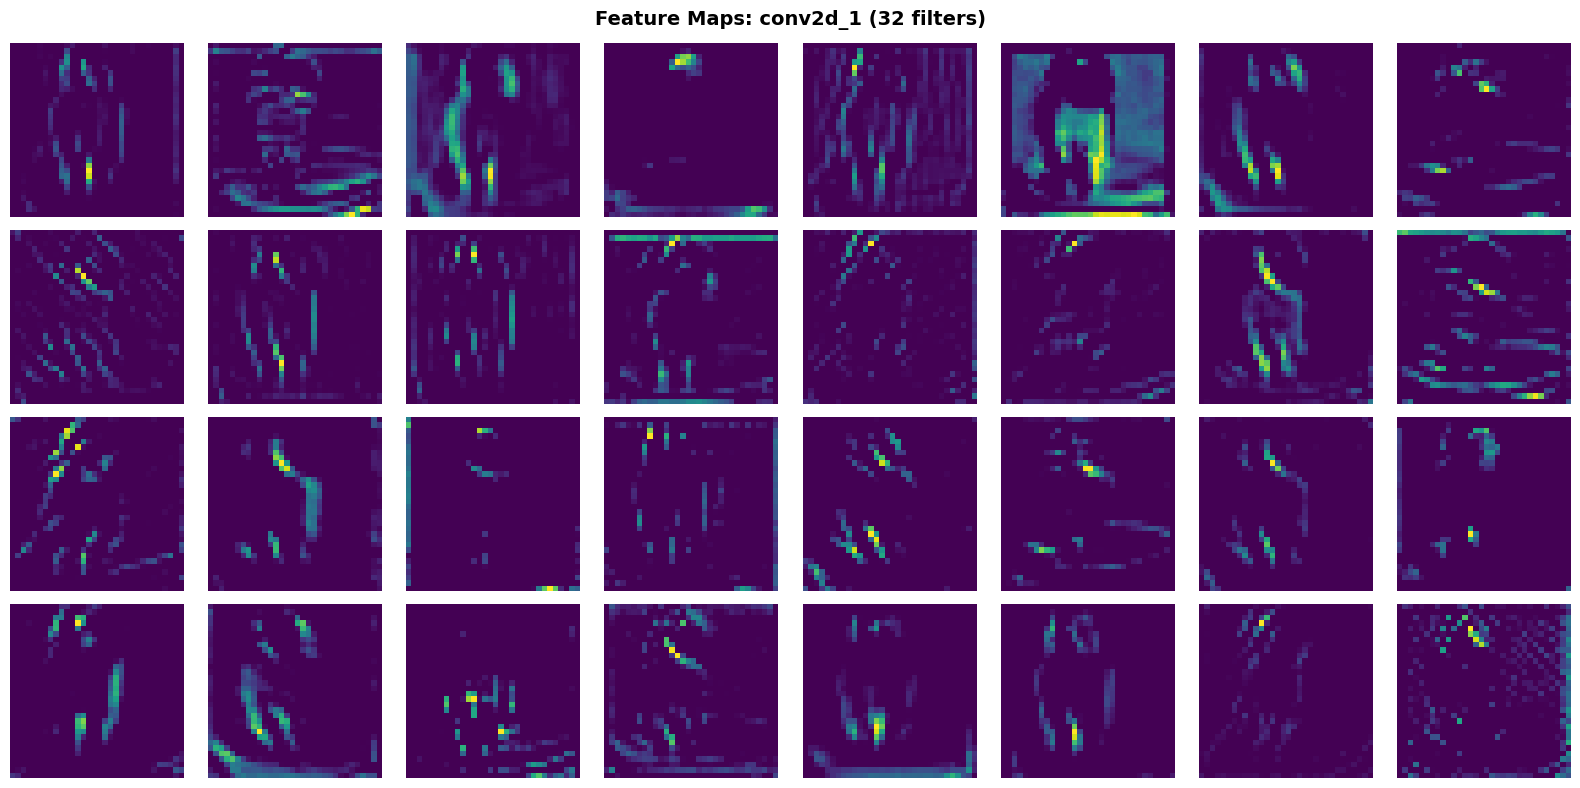

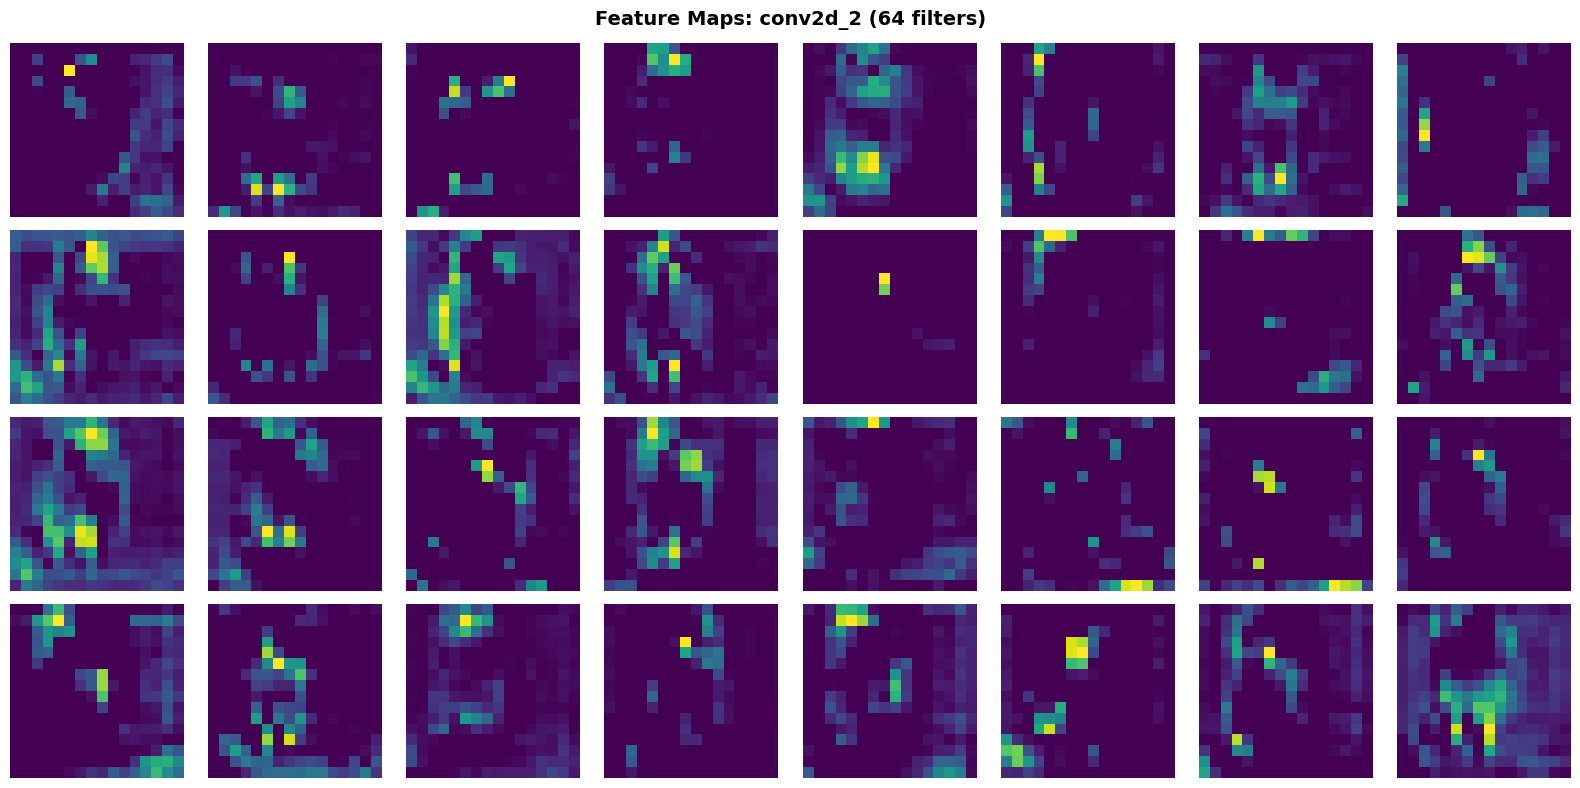

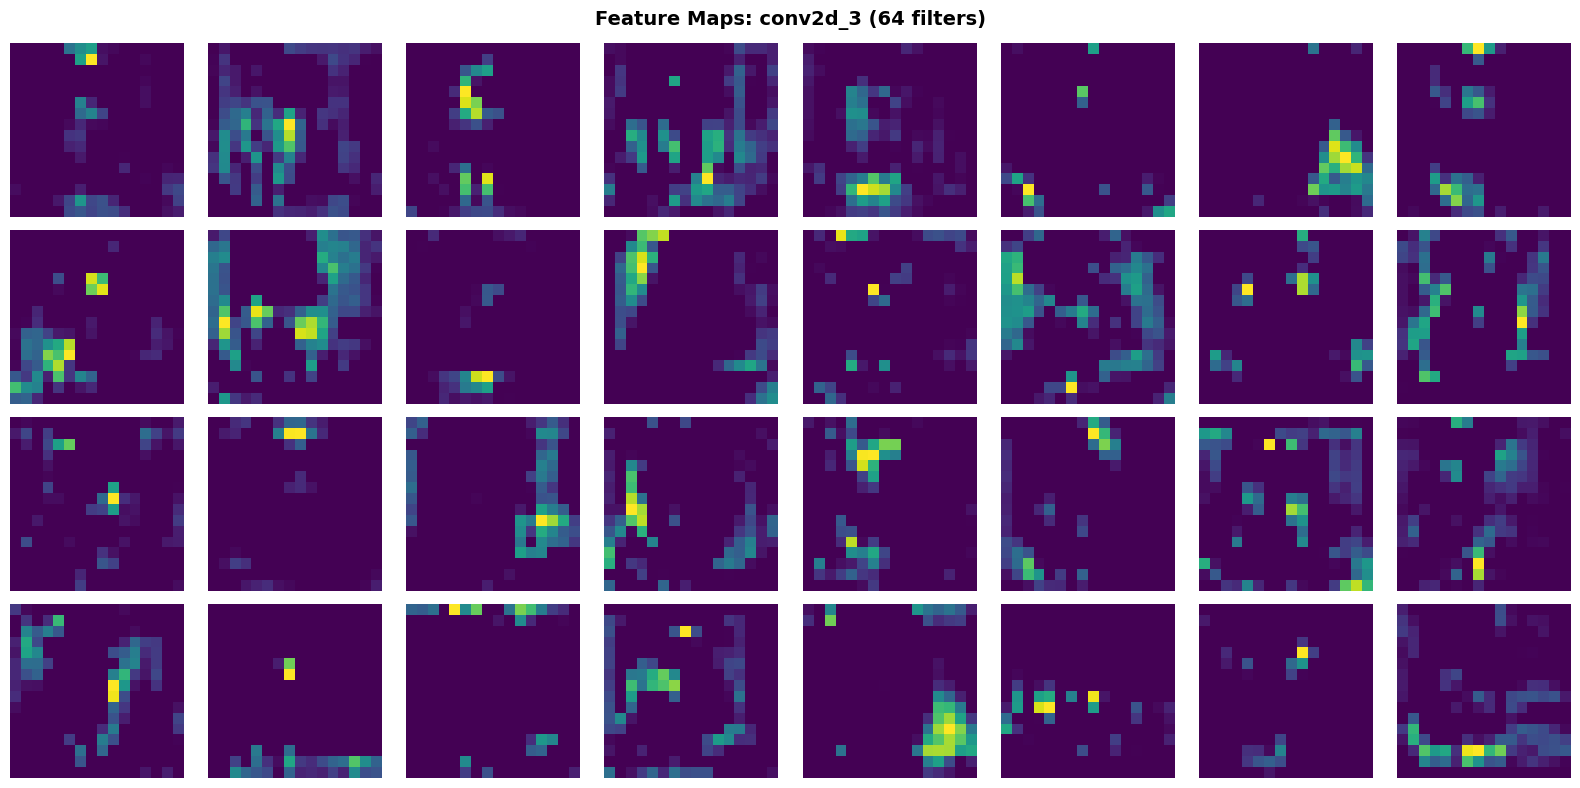


--- Feature Map Visualization for Multiple Classes ---


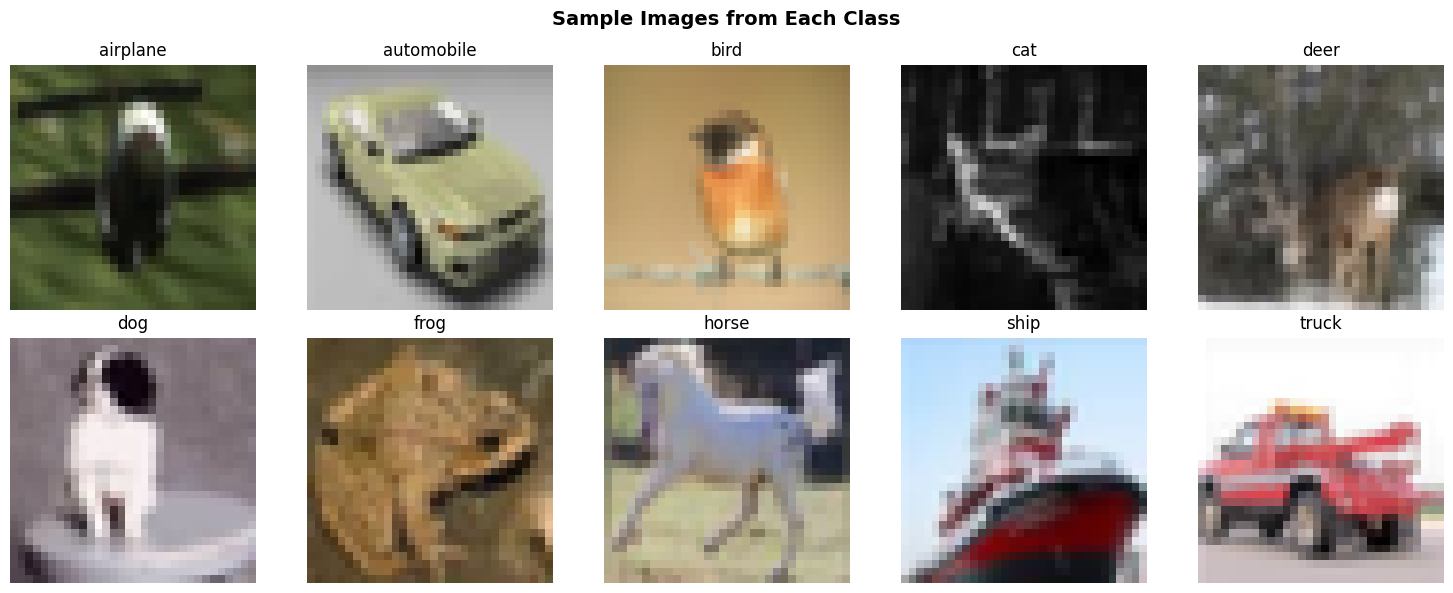

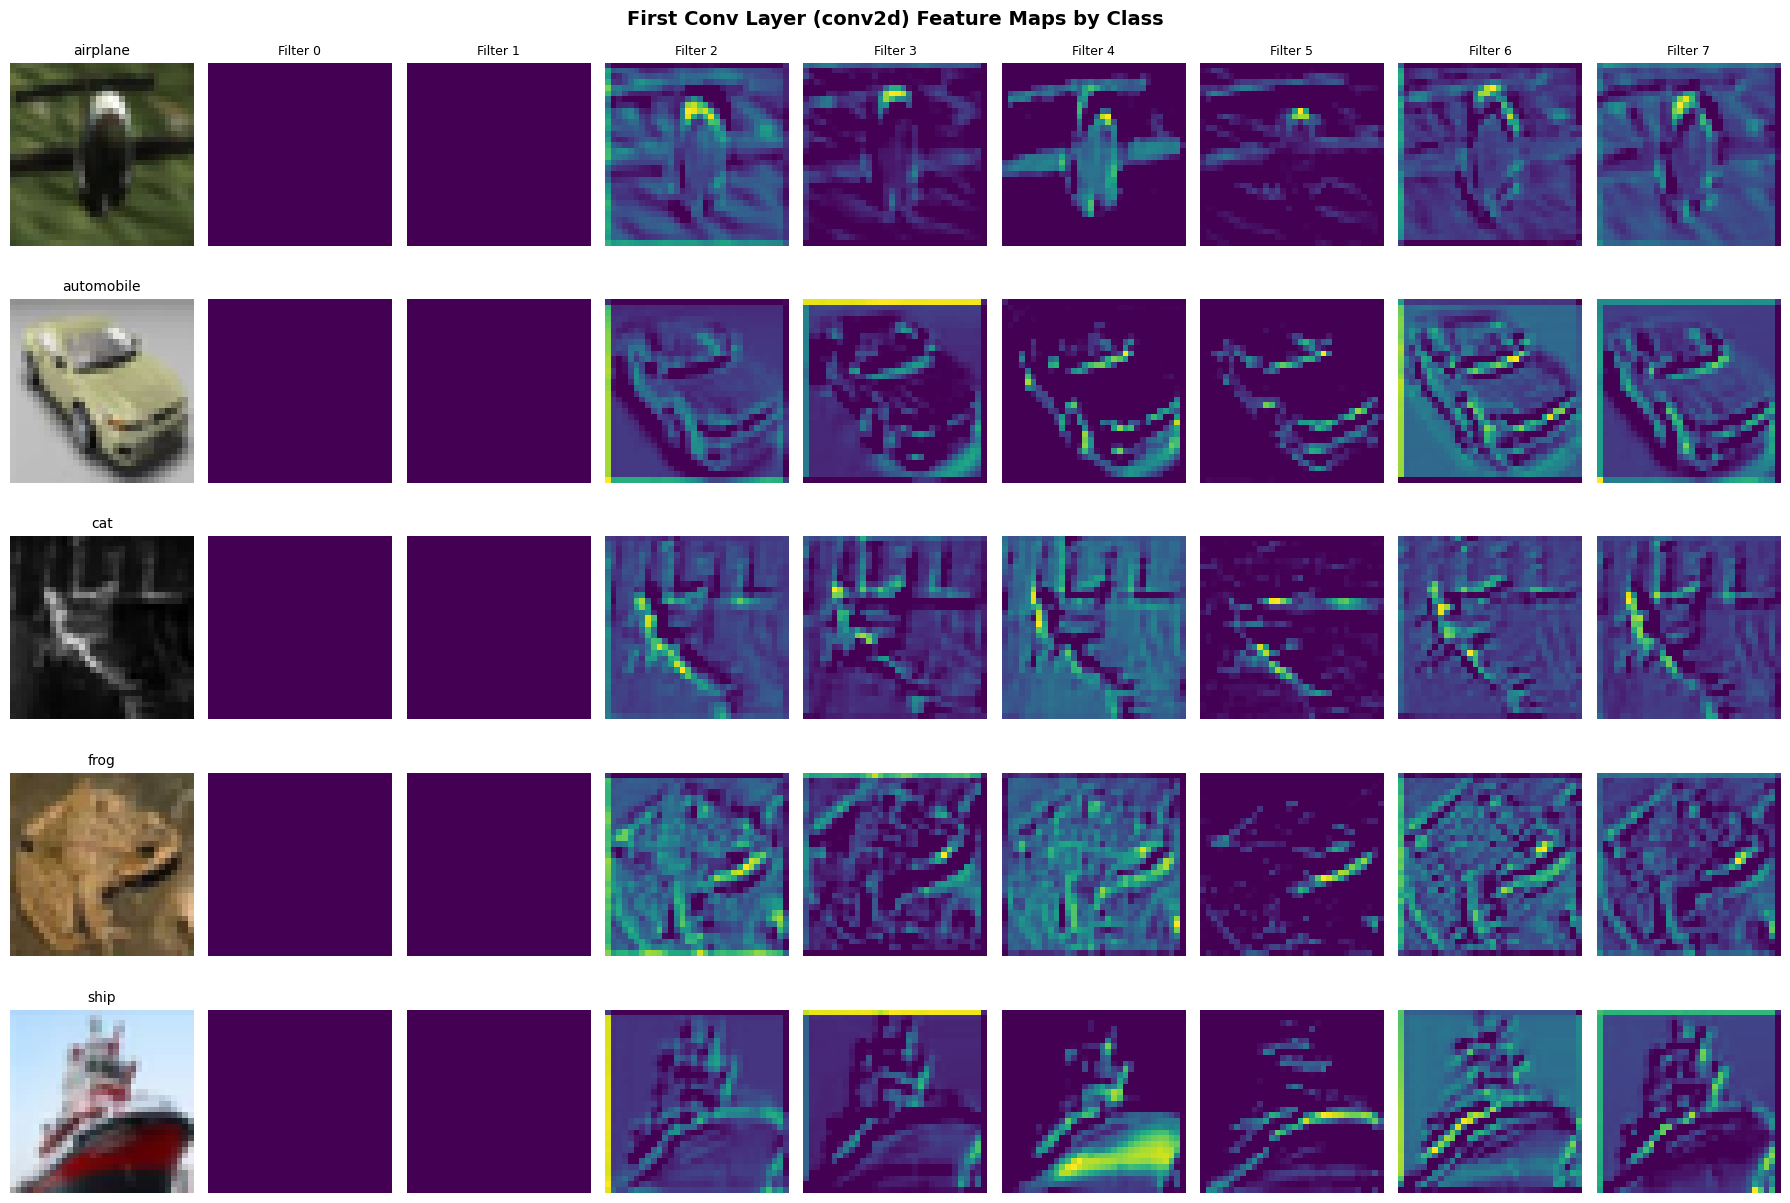


Phase 2 feature map visualization complete!


In [ ]:
# ============================================================
# PHASE 2 Visualize CNN Feature Maps
# ============================================================


# --- CNN Feature Map Visualization ---
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt


inp = Input(shape=(32, 32, 3))
x = inp
conv_layer_names = []
conv_layer_outputs = []

for layer in model_cnn.layers:
    x = layer(x)                          # reuse trained weights
    if 'conv2d' in layer.name:
        conv_layer_names.append(layer.name)
        conv_layer_outputs.append(x)

print(f"Convolutional layers found: {conv_layer_names}")

feature_map_model = Model(inputs=inp, outputs=conv_layer_outputs)

# ---- Data ----
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

sample_idx = 0
sample_image = X_test_dl[sample_idx:sample_idx+1]   # (1, 32, 32, 3)
true_label = np.argmax(y_test_dl[sample_idx])

# ---- Get feature maps for the sample image ----
feature_maps = feature_map_model.predict(sample_image, verbose=0)
if not isinstance(feature_maps, list):
    feature_maps = [feature_maps]

# Show the original image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(f'Original Image: {class_names[true_label]}')
plt.axis('off')
plt.show()

# ---- Visualize feature maps for each conv layer ----
for layer_name, fmap in zip(conv_layer_names, feature_maps):
    n_filters = fmap.shape[-1]
    n_cols = 8
    n_rows = min(4, (n_filters + n_cols - 1) // n_cols)
    n_show = n_rows * n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
    fig.suptitle(f'Feature Maps: {layer_name} ({n_filters} filters)',
                 fontsize=14, fontweight='bold')

    for i in range(n_show):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[col]
        if i < n_filters:
            ax.imshow(fmap[0, :, :, i], cmap='viridis')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# ---- Visualize one sample per class ----
print("\n--- Feature Map Visualization for Multiple Classes ---")

y_test_labels = np.argmax(y_test_dl, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')

for cls_idx in range(10):
    row = cls_idx // 5
    col = cls_idx % 5
    idx = np.where(y_test_labels == cls_idx)[0][0]
    axes[row, col].imshow(X_test_dl[idx])
    axes[row, col].set_title(class_names[cls_idx])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# ---- First-conv-layer feature maps for 5 different classes ----
selected_classes = [0, 1, 3, 6, 8]  # airplane, automobile, cat, frog, ship

fig, axes = plt.subplots(len(selected_classes), 9,
                         figsize=(18, 2.5 * len(selected_classes)))
fig.suptitle(f'First Conv Layer ({conv_layer_names[0]}) Feature Maps by Class',
             fontsize=14, fontweight='bold')

for row_idx, cls_idx in enumerate(selected_classes):
    idx = np.where(y_test_labels == cls_idx)[0][0]
    img = X_test_dl[idx:idx+1]
    fmaps = feature_map_model.predict(img, verbose=0)
    if not isinstance(fmaps, list):
        fmaps = [fmaps]
    first_layer_fmaps = fmaps[0]

    # Original image in first column
    axes[row_idx, 0].imshow(img[0])
    axes[row_idx, 0].set_title(class_names[cls_idx], fontsize=10)
    axes[row_idx, 0].axis('off')

    # First 8 feature maps
    for f_idx in range(8):
        axes[row_idx, f_idx + 1].imshow(
            first_layer_fmaps[0, :, :, f_idx], cmap='viridis')
        axes[row_idx, f_idx + 1].axis('off')
        if row_idx == 0:
            axes[row_idx, f_idx + 1].set_title(f'Filter {f_idx}', fontsize=9)

plt.tight_layout()
plt.show()

print("\nPhase 2 feature map visualization complete!")

In [15]:
# ============================================================================
#  Shared Data Preparation 
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# ---- Load CIFAR‑10 ----
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test_full  = X_test_full.astype('float32')  / 255.0
y_train_full = y_train_full.flatten()
y_test_full  = y_test_full.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = 10

# ---- Create sequences for RNN/GRU/LSTM ----
# Each "sequence" = 3 consecutive same‑class images (simulated video clip)
SEQUENCE_LENGTH = 3

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for cls in range(10):
        idxs = np.where(y == cls)[0]
        for i in range(0, len(idxs) - seq_len + 1, seq_len):
            X_seq.append(X[idxs[i:i + seq_len]])
            y_seq.append(cls)
    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    perm = np.random.permutation(len(y_seq))
    return X_seq[perm], y_seq[perm]

np.random.seed(42)
X_train_seq, y_train_seq = create_sequences(X_train_full, y_train_full, SEQUENCE_LENGTH)
X_test_seq,  y_test_seq  = create_sequences(X_test_full,  y_test_full,  SEQUENCE_LENGTH)

y_train_cat = to_categorical(y_train_seq, num_classes)
y_test_cat  = to_categorical(y_test_seq,  num_classes)

# Also prepare standard (non‑sequence) one‑hot labels for the Transformer
y_train_oh = to_categorical(y_train_full, num_classes)
y_test_oh  = to_categorical(y_test_full,  num_classes)

print(f"Sequence data  — train: {X_train_seq.shape}  test: {X_test_seq.shape}")
print(f"Standard data  — train: {X_train_full.shape}  test: {X_test_full.shape}")

# ---- Helper: evaluate & plot ----
def evaluate_and_plot(model, X_test, y_test_labels, y_test_onehot,
                      history, model_name):
    """Evaluate model, print report, plot curves & confusion matrix."""
    loss, acc = model.evaluate(X_test, y_test_onehot, verbose=0)
    print(f"\n{model_name}  —  Test Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f}")

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test_labels, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test_labels, y_pred)
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    axes[1].plot(history.history['accuracy'],     label='Train')
    axes[1].plot(history.history['val_accuracy'],  label='Validation')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

    axes[2].plot(history.history['loss'],     label='Train')
    axes[2].plot(history.history['val_loss'],  label='Validation')
    axes[2].set_title(f'{model_name} — Loss')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss'); axes[2].legend()

    plt.tight_layout()
    plt.show()

Sequence data  — train: (16660, 3, 32, 32, 3)  test: (3330, 3, 32, 32, 3)
Standard data  — train: (50000, 32, 32, 3)  test: (10000, 32, 32, 3)


Model: "CNN_BiRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_input (InputLayer)          │ (None, 3, 32, 32, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 3, 32, 32, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 3, 32, 32, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 3, 16, 16, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 3, 16, 16, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 3, 16, 16, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 3, 8, 8, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 3, 8, 8, 128)   │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 3, 8, 8, 128)   │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 3, 128)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,122 (758.29 KB)

 Trainable params: 193,674 (756.54 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
222/222 - 25s - 113ms/step - accuracy: 0.4589 - loss: 1.4031 - val_accuracy: 0.4338 - val_loss: 1.5178 - learning_rate: 5.0000e-04
Epoch 2/20
222/222 - 3s - 12ms/step - accuracy: 0.7000 - loss: 0.8103 - val_accuracy: 0.6615 - val_loss: 0.9449 - learning_rate: 5.0000e-04
Epoch 3/20
222/222 - 3s - 13ms/step - accuracy: 0.7708 - loss: 0.6285 - val_accuracy: 0.7171 - val_loss: 0.8499 - learning_rate: 5.0000e-04
Epoch 4/20
222/222 - 3s - 12ms/step - accuracy: 0.8244 - loss: 0.4889 - val_accuracy: 0.7395 - val_loss: 0.7596 - learning_rate: 5.0000e-04
Epoch 5/20
222/222 - 3s - 12ms/step - accuracy: 0.8575 - loss: 0.4060 - val_accuracy: 0.8371 - val_loss: 0.4370 - learning_rate: 5.0000e-04
Epoch 6/20
222/222 - 3s - 12ms/step - accuracy: 0.8774 - loss: 0.3434 - val_accuracy: 0.7751 - val_loss: 0.6260 - learning_rate: 5.0000e-04
Epoch 7/20
222/222 - 3s - 12ms/step - accuracy: 0.8965 - loss: 0.2946 - val_accuracy: 0.6899 - val_loss: 1.1350 - learning_rate: 5.0000e-04
Epoch 8/20

Epoch 

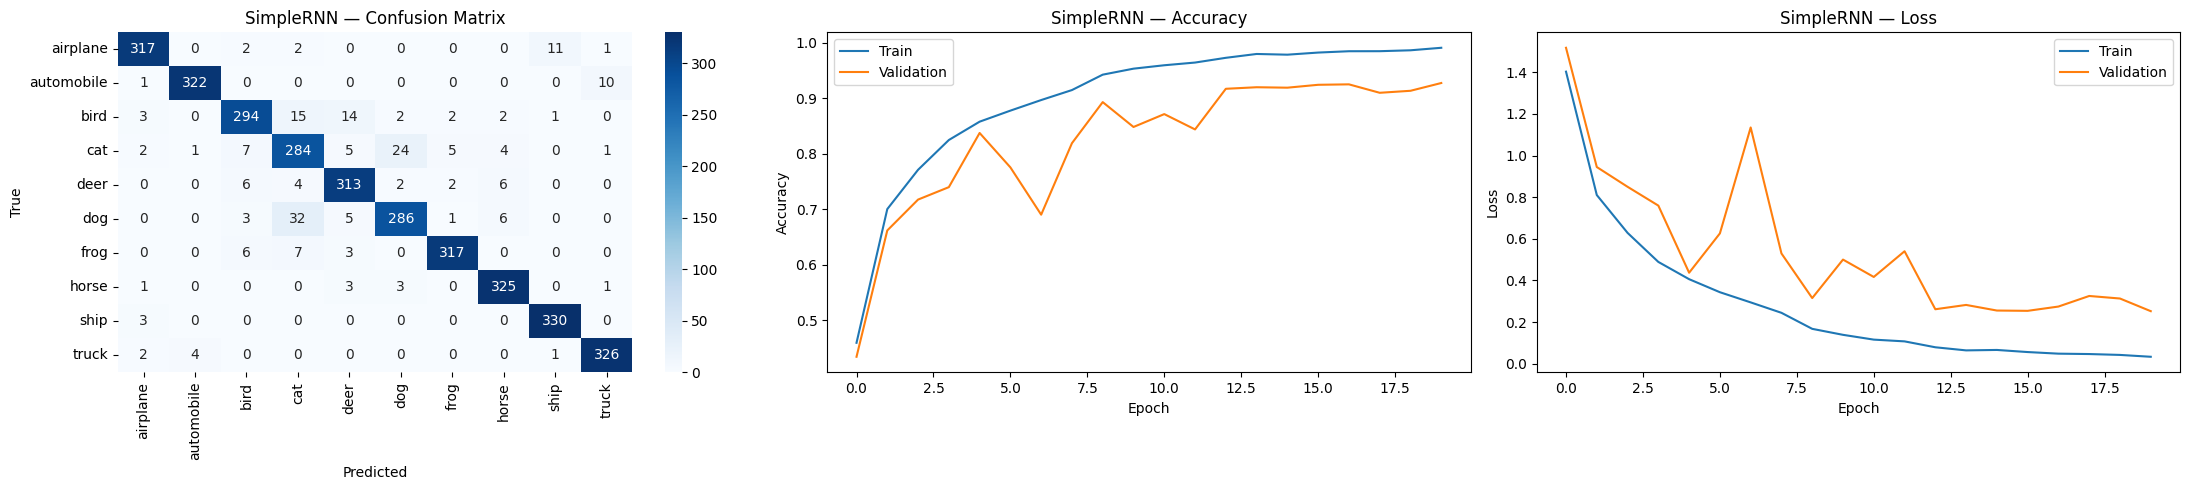

In [16]:
# ============================================================================
#  SimpleRNN Model
# ============================================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    TimeDistributed, SimpleRNN, Bidirectional,
    Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---- Build CNN‑RNN Model ----
seq_input = Input(shape=(SEQUENCE_LENGTH, 32, 32, 3), name='rnn_input')

# TimeDistributed CNN (3 conv blocks)
x = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(seq_input)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling2D((2, 2)))(x)

x = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling2D((2, 2)))(x)

x = TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(GlobalAveragePooling2D())(x)   # → (batch, 3, 128)

# Bidirectional SimpleRNN
x = Bidirectional(SimpleRNN(128, activation='tanh'))(x)   # → (batch, 256)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_rnn = Model(seq_input, outputs, name='CNN_BiRNN')

model_rnn.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_rnn.summary()

# ---- Train ----
history_rnn = model_rnn.fit(
    X_train_seq, y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=2
)

# ---- Evaluate ----
evaluate_and_plot(model_rnn, X_test_seq, y_test_seq, y_test_cat,
                  history_rnn, 'SimpleRNN')

Model: "CNN_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_input (InputLayer)          │ (None, 3, 32, 32, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 3, 32, 32, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 3, 32, 32, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 3, 16, 16, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 3, 16, 16, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 3, 16, 16, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 3, 8, 8, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 3, 8, 8, 128)   │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 3, 8, 8, 128)   │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_17             │ (None, 3, 128)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,474 (1.25 MB)

 Trainable params: 326,026 (1.24 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
222/222 - 19s - 87ms/step - accuracy: 0.5264 - loss: 1.2237 - val_accuracy: 0.5118 - val_loss: 1.3794 - learning_rate: 5.0000e-04
Epoch 2/20
222/222 - 7s - 33ms/step - accuracy: 0.7337 - loss: 0.7157 - val_accuracy: 0.6883 - val_loss: 0.8368 - learning_rate: 5.0000e-04
Epoch 3/20
222/222 - 8s - 34ms/step - accuracy: 0.8036 - loss: 0.5321 - val_accuracy: 0.5934 - val_loss: 1.3748 - learning_rate: 5.0000e-04
Epoch 4/20
222/222 - 7s - 31ms/step - accuracy: 0.8370 - loss: 0.4397 - val_accuracy: 0.7727 - val_loss: 0.6325 - learning_rate: 5.0000e-04
Epoch 5/20
222/222 - 7s - 33ms/step - accuracy: 0.8701 - loss: 0.3678 - val_accuracy: 0.8487 - val_loss: 0.4214 - learning_rate: 5.0000e-04
Epoch 6/20
222/222 - 7s - 31ms/step - accuracy: 0.8905 - loss: 0.3124 - val_accuracy: 0.8091 - val_loss: 0.5780 - learning_rate: 5.0000e-04
Epoch 7/20
222/222 - 7s - 33ms/step - accuracy: 0.9071 - loss: 0.2686 - val_accuracy: 0.8828 - val_loss: 0.3304 - learning_rate: 5.0000e-04
Epoch 8/20
222/222 

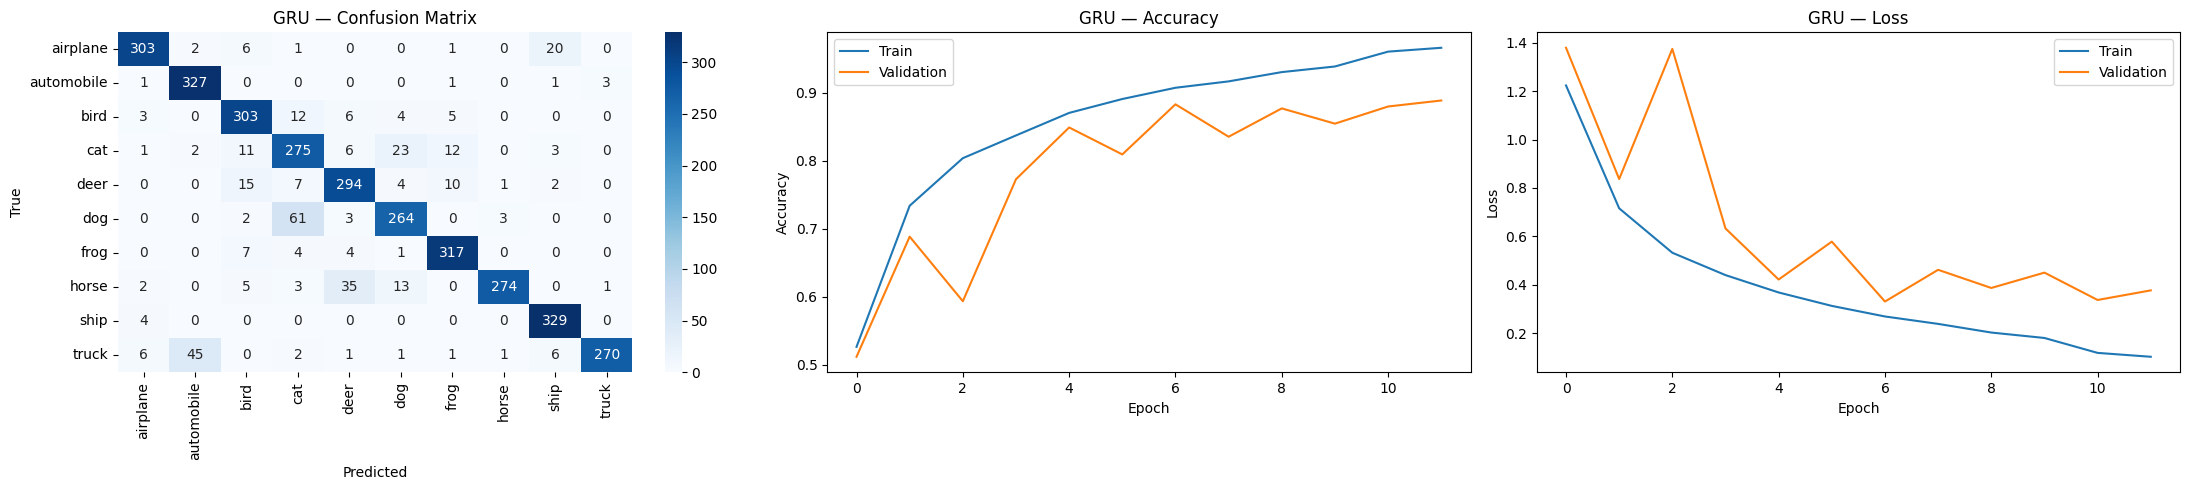

In [17]:
# ============================================================================
#  GRU Model 
# ============================================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    TimeDistributed, GRU, Bidirectional,
    Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---- Build CNN‑GRU Model ----
seq_input = Input(shape=(SEQUENCE_LENGTH, 32, 32, 3), name='gru_input')

# TimeDistributed CNN (3 conv blocks)
x = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(seq_input)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling2D((2, 2)))(x)

x = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling2D((2, 2)))(x)

x = TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(GlobalAveragePooling2D())(x)   # → (batch, 3, 128)

# Bidirectional GRU
x = Bidirectional(GRU(128, activation='tanh', dropout=0.2))(x)   # → (batch, 256)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_gru = Model(seq_input, outputs, name='CNN_GRU')

model_gru.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_gru.summary()

# ---- Train ----
history_gru = model_gru.fit(
    X_train_seq, y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=2
)

# ---- Evaluate ----
evaluate_and_plot(model_gru, X_test_seq, y_test_seq, y_test_cat,
                  history_gru, 'GRU')

Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_att_input (InputLayer)     │ (None, 3, 32, 32, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_18             │ (None, 3, 32, 32, 32)  │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_19             │ (None, 3, 32, 32, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_20             │ (None, 3, 16, 16, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_21             │ (None, 3, 16, 16, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_22             │ (None, 3, 16, 16, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_23             │ (None, 3, 8, 8, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_24             │ (None, 3, 8, 8, 128)   │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_25             │ (None, 3, 8, 8, 128)   │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_26             │ (None, 3, 128)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 3, 256)         │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 256)            │        66,048 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,546 (1.75 MB)

 Trainable params: 457,098 (1.74 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
222/222 - 16s - 73ms/step - accuracy: 0.4908 - loss: 1.3056 - val_accuracy: 0.5266 - val_loss: 1.1919 - learning_rate: 5.0000e-04
Epoch 2/20
222/222 - 7s - 32ms/step - accuracy: 0.7127 - loss: 0.7660 - val_accuracy: 0.6967 - val_loss: 0.8014 - learning_rate: 5.0000e-04
Epoch 3/20
222/222 - 8s - 34ms/step - accuracy: 0.7880 - loss: 0.5794 - val_accuracy: 0.5290 - val_loss: 1.6588 - learning_rate: 5.0000e-04
Epoch 4/20
222/222 - 7s - 32ms/step - accuracy: 0.8247 - loss: 0.4793 - val_accuracy: 0.7975 - val_loss: 0.5362 - learning_rate: 5.0000e-04
Epoch 5/20
222/222 - 8s - 34ms/step - accuracy: 0.8491 - loss: 0.4188 - val_accuracy: 0.6823 - val_loss: 0.9755 - learning_rate: 5.0000e-04
Epoch 6/20
222/222 - 7s - 33ms/step - accuracy: 0.8761 - loss: 0.3512 - val_accuracy: 0.7943 - val_loss: 0.5742 - learning_rate: 5.0000e-04
Epoch 7/20
222/222 - 8s - 34ms/step - accuracy: 0.8881 - loss: 0.3142 - val_accuracy: 0.8595 - val_loss: 0.4175 - learning_rate: 5.0000e-04
Epoch 8/20
222/222 

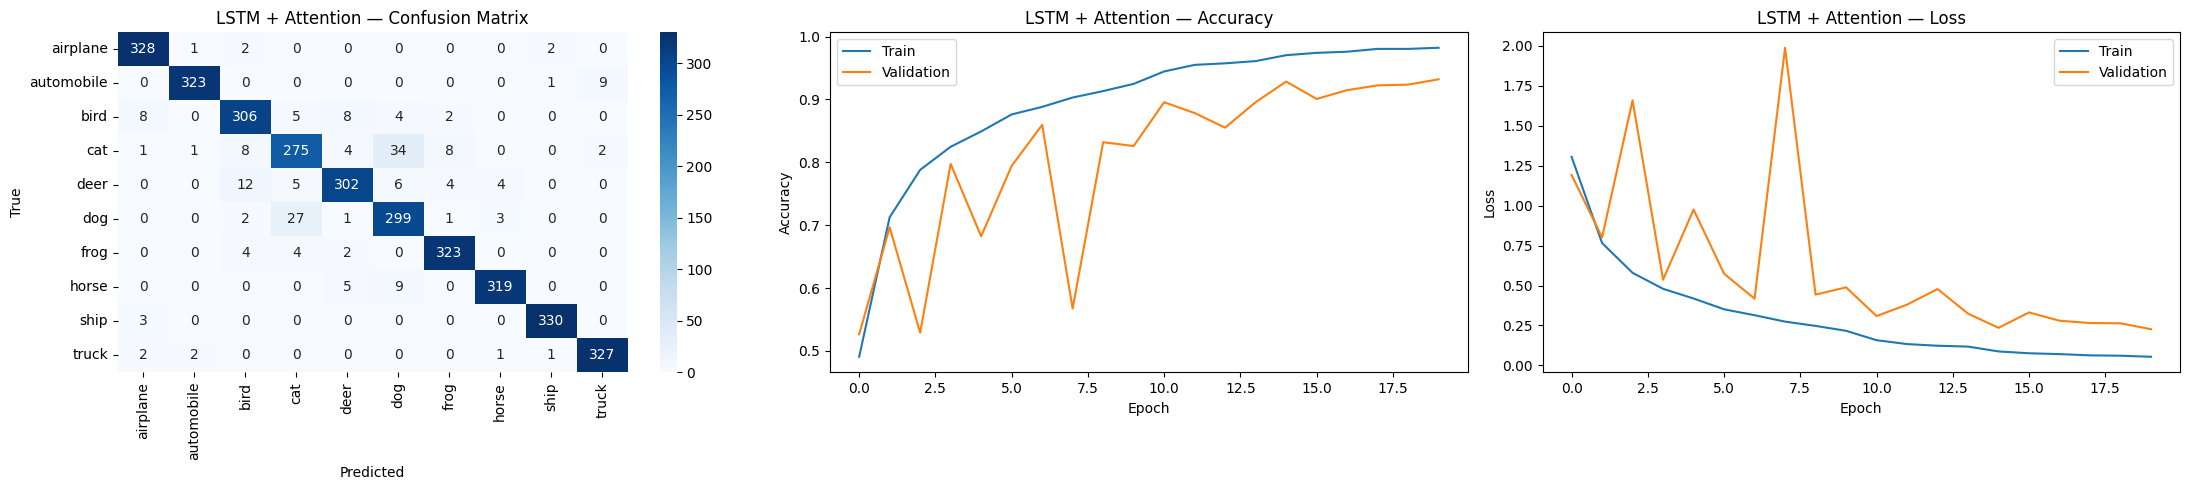

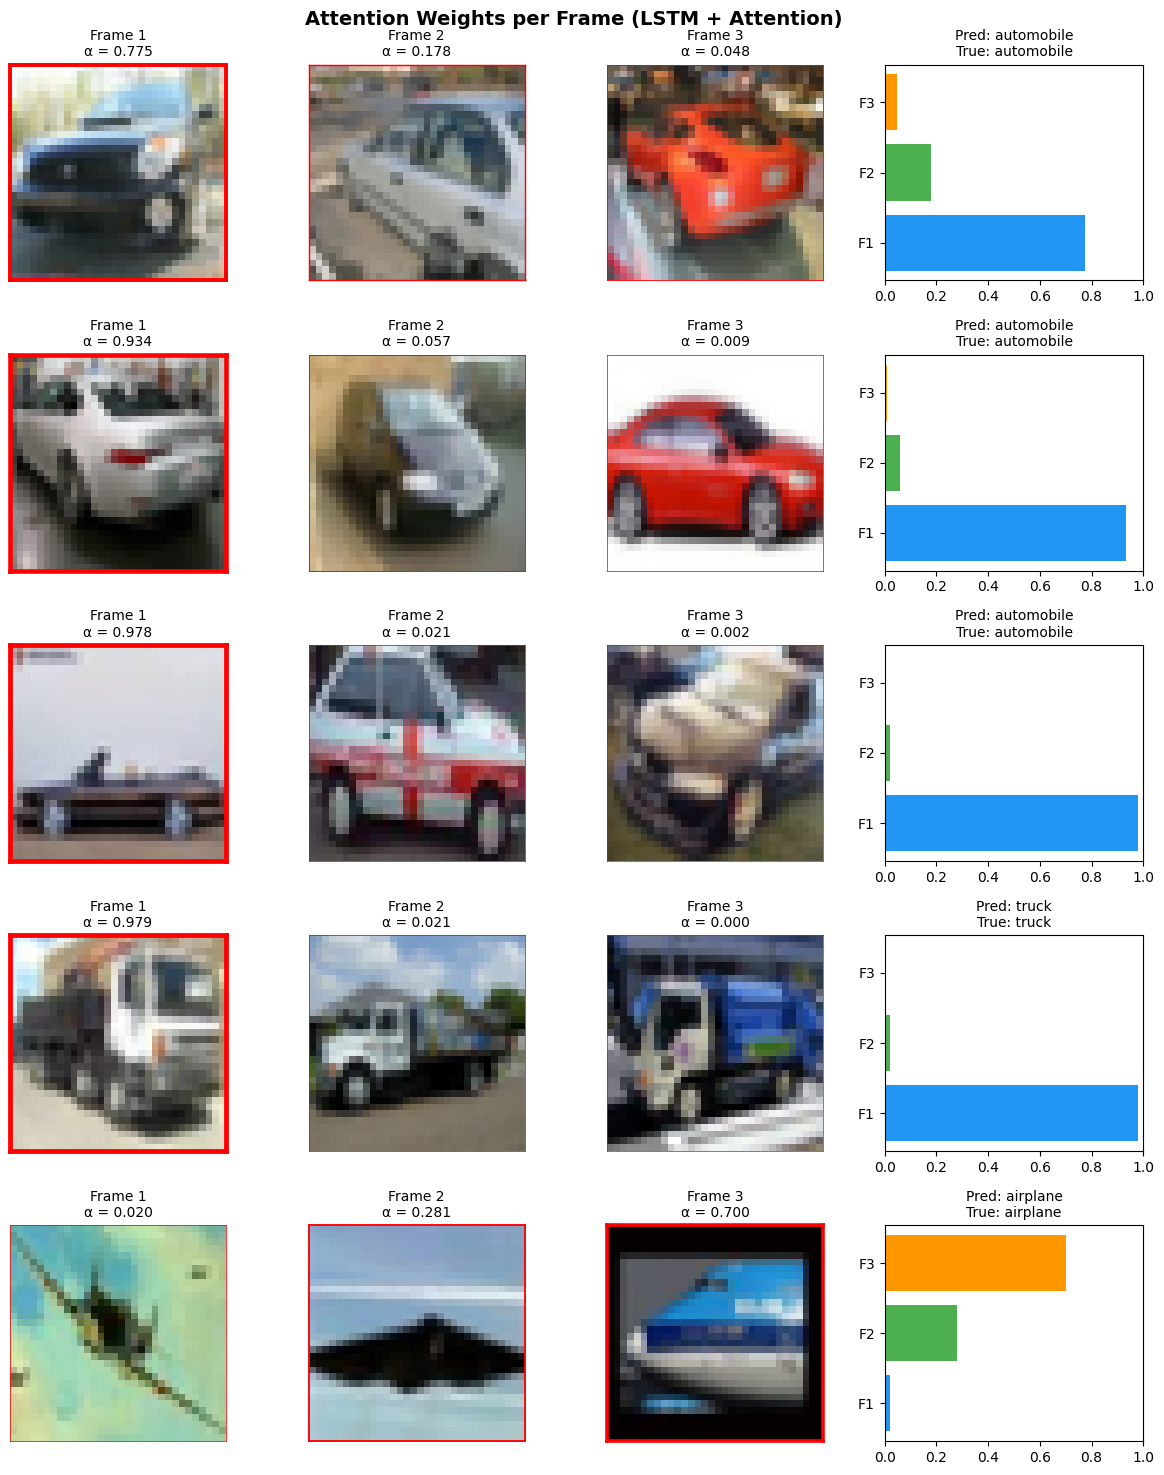

LSTM + Attention visualization complete!


In [18]:
# ========================
#  LSTM + Attention Model 
# ========================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    TimeDistributed, LSTM, Bidirectional,
    Dense, Dropout, GlobalAveragePooling2D, Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt


# ---- Custom Attention Layer ----
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='att_weight',
            shape=(int(input_shape[-1]), int(input_shape[-1])),
            initializer='glorot_uniform',
            trainable=True
        )
        self.V = self.add_weight(
            name='att_score',
            shape=(int(input_shape[-1]), 1),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='att_bias',
            shape=(int(input_shape[-1]),),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x, return_attention=False):
        # x: (batch, T, features)
        score = tf.keras.activations.tanh(
            tf.matmul(x, self.W) + self.b
        )                                              # (batch, T, features)
        attention_weights = tf.keras.activations.softmax(
            tf.matmul(score, self.V), axis=1
        )                                              # (batch, T, 1)
        context = tf.reduce_sum(x * attention_weights, axis=1)  # (batch, features)
        if return_attention:
            return context, tf.squeeze(attention_weights, axis=-1)
        return context

    def get_config(self):
        return super().get_config()


# ---- Build CNN‑LSTM + Attention Model ----
seq_input = Input(shape=(SEQUENCE_LENGTH, 32, 32, 3), name='lstm_att_input')

#TimeDistributed CNN (3 conv blocks)
x = TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'))(seq_input)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling2D((2, 2)))(x)

x = TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(MaxPooling2D((2, 2)))(x)

x = TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same'))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(GlobalAveragePooling2D())(x)   # (batch, 3, 128)

# Bidirectional LSTM — return all timestep outputs for attention
x = Bidirectional(
    LSTM(128, activation='tanh', dropout=0.2, return_sequences=True)
)(x)                                                # (batch, 3, 256)

# Attention — learn which frames matter
attention_layer = AttentionLayer()
x = attention_layer(x)                              # (batch, 256)

# Classification head
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model_lstm = Model(seq_input, outputs, name='CNN_BiLSTM_Attention')

model_lstm.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_lstm.summary()

# ---- Train ----
history_lstm = model_lstm.fit(
    X_train_seq, y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=2
)

# ---- Evaluate ----
evaluate_and_plot(model_lstm, X_test_seq, y_test_seq, y_test_cat,
                  history_lstm, 'LSTM + Attention')


# ---- Visualize Attention Weights ----
att_vis_input = Input(shape=(SEQUENCE_LENGTH, 32, 32, 3))
x_vis = att_vis_input
for layer in model_lstm.layers[1:]:  # skip input layer
    if layer.name == attention_layer.name:
        x_vis, att_weights = layer(x_vis, return_attention=True)
    else:
        x_vis = layer(x_vis)

att_model = Model(att_vis_input, [x_vis, att_weights])

# Show attention for a few test sequences
n_show = 5
sample_seqs = X_test_seq[:n_show]
preds, attn = att_model.predict(sample_seqs, verbose=0)
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(n_show, SEQUENCE_LENGTH + 1, figsize=(12, 3 * n_show))
fig.suptitle('Attention Weights per Frame (LSTM + Attention)',
             fontsize=14, fontweight='bold')

for i in range(n_show):
    for t in range(SEQUENCE_LENGTH):
        axes[i, t].imshow(sample_seqs[i, t])
        axes[i, t].set_title(f'Frame {t+1}\nα = {attn[i, t]:.3f}',
                             fontsize=10)
        # Highlight border based on attention weight
        for spine in axes[i, t].spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3 * attn[i, t] + 0.5)
        axes[i, t].set_xticks([]); axes[i, t].set_yticks([])

    # Show attention bar
    axes[i, SEQUENCE_LENGTH].barh(
        [f'F{t+1}' for t in range(SEQUENCE_LENGTH)],
        attn[i], color=['#2196F3', '#4CAF50', '#FF9800']
    )
    axes[i, SEQUENCE_LENGTH].set_xlim(0, 1)
    axes[i, SEQUENCE_LENGTH].set_title(
        f'Pred: {class_names[pred_labels[i]]}\n'
        f'True: {class_names[y_test_seq[i]]}', fontsize=10
    )

plt.tight_layout()
plt.show()

print("LSTM + Attention visualization complete!")

Model: "VisionTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_9[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extract       │ (None, None, 48)  │          0 │ data_augmentatio… │
│ (PatchExtract)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 65, 96)    │     11,040 │ patch_extract[0]… │
│ (PatchEmbedding)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 65, 96)    │     37,248 │ patch_embedding[… │
│ (MultiHeadAttentio… │                   │            │ patch_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 65, 96)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 65, 96)    │          0 │ patch_embedding[… │
│                     │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 65, 96)    │        192 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 65, 256)   │     24,832 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 65, 256)   │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 65, 96)    │     24,672 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 65, 96)    │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 65, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 65, 96)    │        192 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 65, 96)    │     37,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 65, 96)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 65, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 561,450 (2.14 MB)

 Trainable params: 561,450 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
333/333 - 62s - 185ms/step - accuracy: 0.1462 - loss: 2.3576 - val_accuracy: 0.2192 - val_loss: 2.0785
Epoch 2/50
333/333 - 32s - 96ms/step - accuracy: 0.2562 - loss: 2.0177 - val_accuracy: 0.3389 - val_loss: 1.8593
Epoch 3/50
333/333 - 31s - 92ms/step - accuracy: 0.3408 - loss: 1.8529 - val_accuracy: 0.3640 - val_loss: 1.8914
Epoch 4/50
333/333 - 30s - 91ms/step - accuracy: 0.4370 - loss: 1.6993 - val_accuracy: 0.4227 - val_loss: 1.7730
Epoch 5/50
333/333 - 31s - 93ms/step - accuracy: 0.4838 - loss: 1.6112 - val_accuracy: 0.4840 - val_loss: 1.6070
Epoch 6/50
333/333 - 30s - 89ms/step - accuracy: 0.5228 - loss: 1.5416 - val_accuracy: 0.5515 - val_loss: 1.4591
Epoch 7/50
333/333 - 30s - 89ms/step - accuracy: 0.5506 - loss: 1.4902 - val_accuracy: 0.5433 - val_loss: 1.4982
Epoch 8/50
333/333 - 30s - 91ms/step - accuracy: 0.5739 - loss: 1.4413 - val_accuracy: 0.5521 - val_loss: 1.4749
Epoch 9/50
333/333 - 30s - 91ms/step - accuracy: 0.5876 - loss: 1.4119 - val_accuracy: 0.5205 -

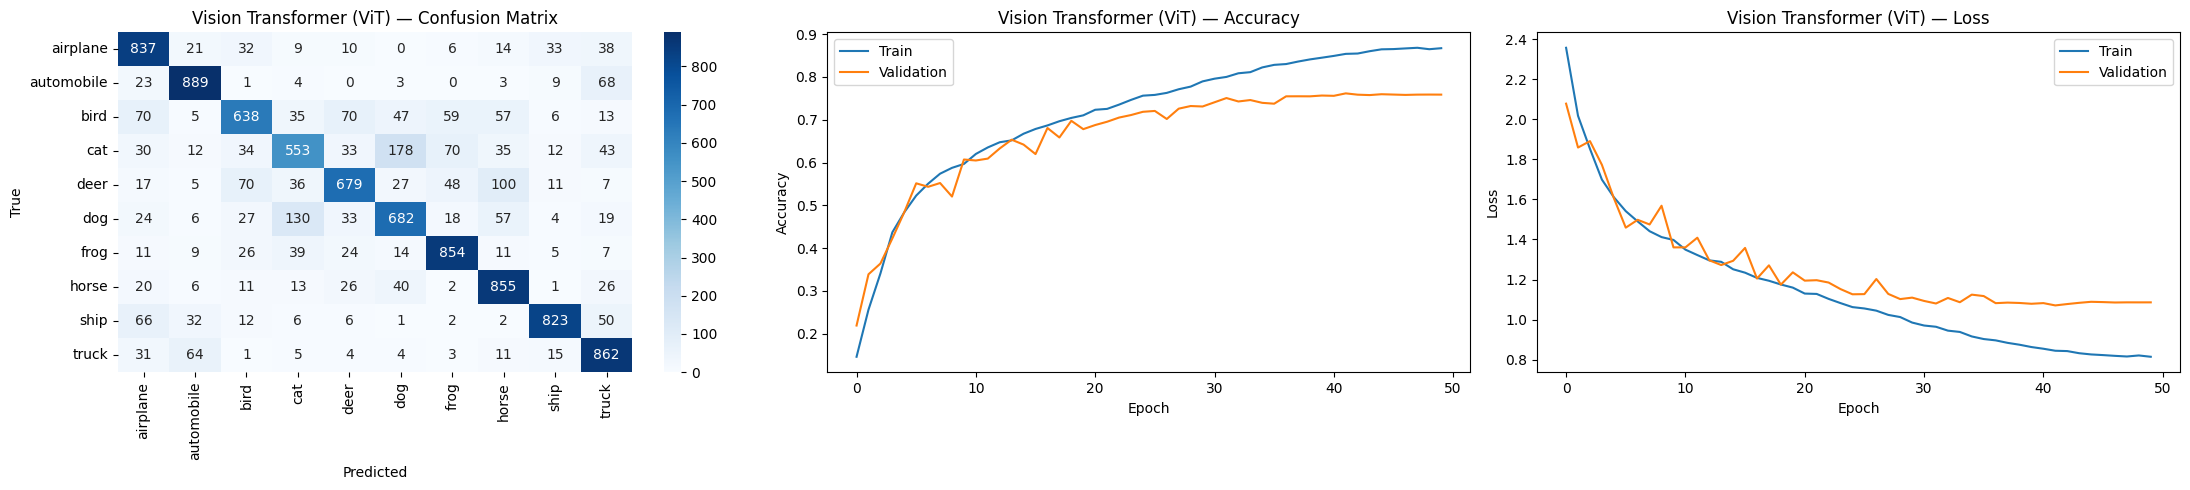

In [19]:
# =======================================
#  Vision Transformer (ViT) Fine‑Tuning
# ======================================


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D,
    Reshape, Embedding, Add, Layer
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt


IMAGE_SIZE   = 32
PATCH_SIZE   = 4          
NUM_PATCHES  = (IMAGE_SIZE // PATCH_SIZE) ** 2   
PROJECTION_DIM = 96      
NUM_HEADS    = 6           
TRANSFORMER_LAYERS = 6    
MLP_DIM      = 256         
DROPOUT_RATE = 0.1
EPOCHS       = 50          
BATCH_SIZE   = 128


# ---- Data augmentation ----
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom((-0.1, 0.0)),
], name='data_augmentation')


# ---- Patch extraction layer ----
class PatchExtract(Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({'patch_size': self.patch_size})
        return config


# ---- Patch embedding + class token + positional embedding ----
class PatchEmbedding(Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches    = num_patches
        self.projection_dim = projection_dim
        self.projection     = Dense(projection_dim)
        # +1 for [CLS] token
        self.position_embedding = Embedding(
            input_dim=num_patches + 1, output_dim=projection_dim
        )

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name='cls_token',
            shape=(1, 1, self.projection_dim),
            initializer='zeros',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, patch):
        batch_size = tf.shape(patch)[0]
        projected  = self.projection(patch)          # (B, N, D)
        cls_tokens = tf.broadcast_to(
            self.cls_token, [batch_size, 1, self.projection_dim]
        )
        projected = tf.concat([cls_tokens, projected], axis=1)   # (B, N+1, D)
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return projected + self.position_embedding(positions)

    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches,
                       'projection_dim': self.projection_dim})
        return config


# ---- Transformer encoder block ----
def transformer_encoder(x, num_heads, projection_dim, mlp_dim, dropout):
    # Multi‑Head Self‑Attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim // num_heads
    )(x, x)
    attn_output = Dropout(dropout)(attn_output)
    x1 = LayerNormalization(epsilon=1e-6)(x + attn_output)

    # MLP (2‑layer with GELU)
    mlp_output = Dense(mlp_dim, activation='gelu')(x1)
    mlp_output = Dropout(dropout)(mlp_output)
    mlp_output = Dense(projection_dim)(mlp_output)
    mlp_output = Dropout(dropout)(mlp_output)
    return LayerNormalization(epsilon=1e-6)(x1 + mlp_output)


# ---- Build improved Vision Transformer ----
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Augmentation (only during training)
augmented = data_augmentation(inputs)

# Extract & embed patches (with [CLS] token)
patches = PatchExtract(PATCH_SIZE)(augmented)
encoded = PatchEmbedding(NUM_PATCHES, PROJECTION_DIM)(patches)

# Transformer encoder blocks
for _ in range(TRANSFORMER_LAYERS):
    encoded = transformer_encoder(
        encoded, NUM_HEADS, PROJECTION_DIM, MLP_DIM, DROPOUT_RATE
    )

# Use [CLS] token output (index 0) instead of global average pooling
cls_output     = LayerNormalization(epsilon=1e-6)(encoded[:, 0])
representation = Dropout(0.3)(cls_output)
features       = Dense(MLP_DIM, activation='gelu')(representation)
features       = Dropout(0.3)(features)
outputs        = Dense(num_classes, activation='softmax')(features)

model_vit = Model(inputs, outputs, name='VisionTransformer')

# ---- Cosine decay LR with warmup ----
total_steps  = (len(X_train_full) * 0.85 // BATCH_SIZE) * EPOCHS  # approx
warmup_steps = int(total_steps * 0.1)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=int(total_steps - warmup_steps),
    alpha=1e-5,
)

# Simple linear warmup wrapper
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, decay_schedule):
        super().__init__()
        self.base_lr       = base_lr
        self.warmup_steps  = warmup_steps
        self.decay_schedule = decay_schedule

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.base_lr * (step / tf.cast(self.warmup_steps, tf.float32))
        decay_lr  = self.decay_schedule(step - tf.cast(self.warmup_steps, tf.float32))
        return tf.cond(step < tf.cast(self.warmup_steps, tf.float32),
                       lambda: warmup_lr, lambda: decay_lr)

    def get_config(self):
        return {'base_lr': self.base_lr, 'warmup_steps': self.warmup_steps}

optimizer = AdamW(learning_rate=WarmUpCosine(1e-3, warmup_steps, lr_schedule), weight_decay=1e-4)

model_vit.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
model_vit.summary()

# ---- Train improved ViT ----
history_vit = model_vit.fit(
    X_train_full, y_train_oh,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ],
    verbose=2
)

# ---- Evaluate ViT ----
evaluate_and_plot(model_vit, X_test_full, y_test_full, y_test_oh,
                  history_vit, 'Vision Transformer (ViT)')


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 16384)          │     1,654,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,312,835 (8.82 MB)

 Trainable params: 2,312,451 (8.82 MB)

 Non-trainable params: 384 (1.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,841 (327.50 KB)

 Trainable params: 83,841 (327.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 10/50  D loss: 0.6871  D acc: 0.3929  G loss: 0.4552
Epoch 20/50  D loss: 0.6923  D acc: 0.3826  G loss: 0.3741
Epoch 30/50  D loss: 0.6957  D acc: 0.3782  G loss: 0.3204
Epoch 40/50  D loss: 0.6988  D acc: 0.3746  G loss: 0.2789
Epoch 50/50  D loss: 0.7021  D acc: 0.3700  G loss: 0.2467


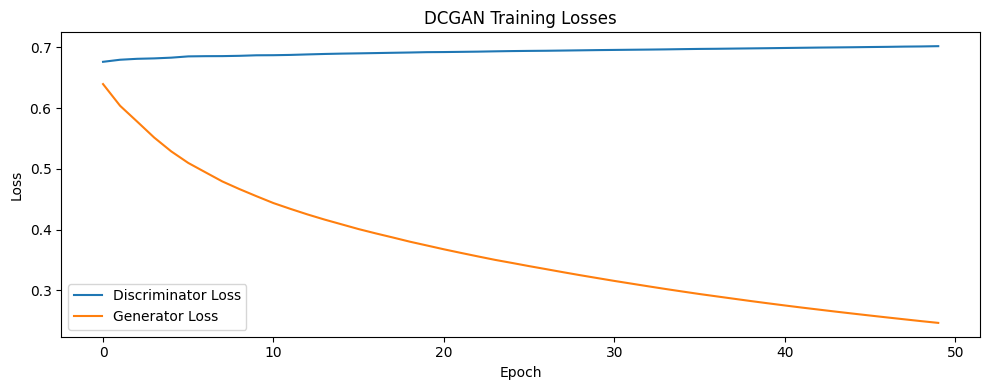

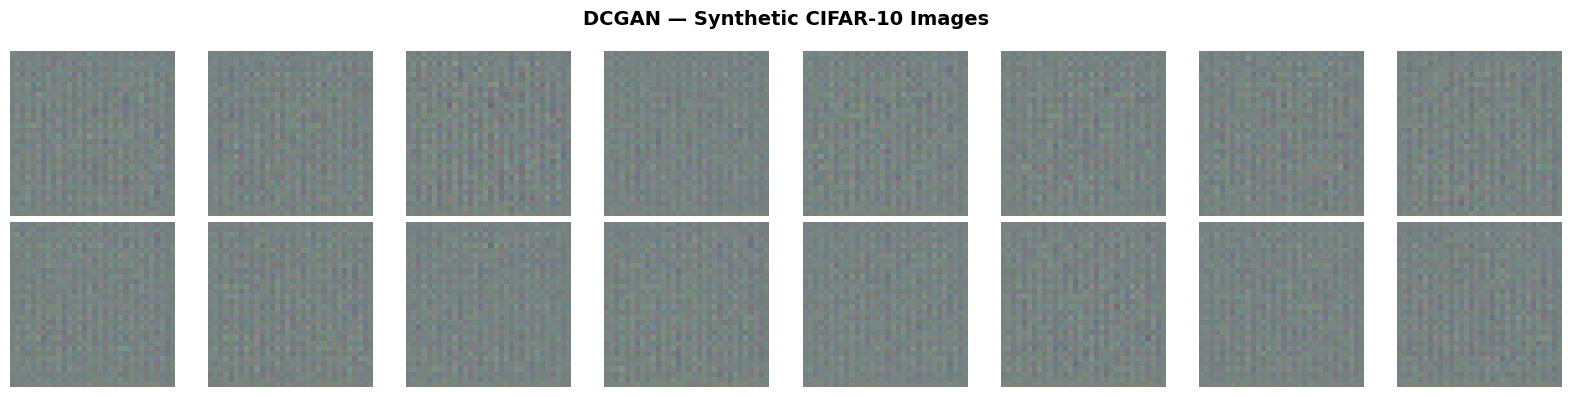

In [20]:
# ============================================================================
#  DCGAN: Generate Synthetic CIFAR‑10 Images
# ============================================================================

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Reshape, Conv2DTranspose, Conv2D, LeakyReLU,
    BatchNormalization, Flatten, Dropout, Input
)
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

LATENT_DIM = 100
IMG_SHAPE  = (32, 32, 3)

# ---- Generator ----
def build_generator():
    model = Sequential([
        Dense(256 * 8 * 8, input_dim=LATENT_DIM),
        Reshape((8, 8, 256)),
        Conv2DTranspose(128, (4, 4), strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        Conv2DTranspose(64, (4, 4), strides=2, padding='same'),
        BatchNormalization(),
        LeakyReLU(0.2),
        Conv2D(3, (3, 3), padding='same', activation='tanh'),
    ], name='Generator')
    return model

# ---- Discriminator ----
def build_discriminator():
    model = Sequential([
        Conv2D(64, (3, 3), strides=2, padding='same', input_shape=IMG_SHAPE),
        LeakyReLU(0.2),
        Dropout(0.3),
        Conv2D(128, (3, 3), strides=2, padding='same'),
        LeakyReLU(0.2),
        Dropout(0.3),
        Flatten(),
        Dense(1, activation='sigmoid'),
    ], name='Discriminator')
    return model

generator     = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

# ---- Compile discriminator ----
discriminator.compile(
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ---- Combined GAN (generator trains, discriminator frozen) ----
discriminator.trainable = False
gan_input  = Input(shape=(LATENT_DIM,))
gan_output = discriminator(generator(gan_input))
gan = Model(gan_input, gan_output, name='DCGAN')
gan.compile(
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy'
)

# ---- Prepare real data (scale to [‑1, 1] for tanh) ----
(X_real, _), (_, _) = cifar10.load_data()
X_real = (X_real.astype('float32') - 127.5) / 127.5

# ---- Training loop ----
EPOCHS     = 50
BATCH_SIZE = 128
HALF_BATCH = BATCH_SIZE // 2

d_losses, g_losses = [], []

for epoch in range(EPOCHS):
    # --- Train Discriminator ---
    idx  = np.random.randint(0, X_real.shape[0], HALF_BATCH)
    real = X_real[idx]
    noise = np.random.normal(0, 1, (HALF_BATCH, LATENT_DIM))
    fake  = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real,  np.ones((HALF_BATCH, 1)))
    d_loss_fake = discriminator.train_on_batch(fake,  np.zeros((HALF_BATCH, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # --- Train Generator ---
    noise  = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    g_loss = gan.train_on_batch(noise, np.ones((BATCH_SIZE, 1)))

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  D loss: {d_loss[0]:.4f}  "
              f"D acc: {d_loss[1]:.4f}  G loss: {g_loss:.4f}")

# ---- Plot losses ----
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('DCGAN Training Losses')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ---- Show generated images ----
noise = np.random.normal(0, 1, (16, LATENT_DIM))
gen_imgs = generator.predict(noise, verbose=0)
gen_imgs = 0.5 * gen_imgs + 0.5  # rescale to [0, 1]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('DCGAN — Synthetic CIFAR‑10 Images', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(gen_imgs[i])
    ax.axis('off')
plt.tight_layout(); plt.show()

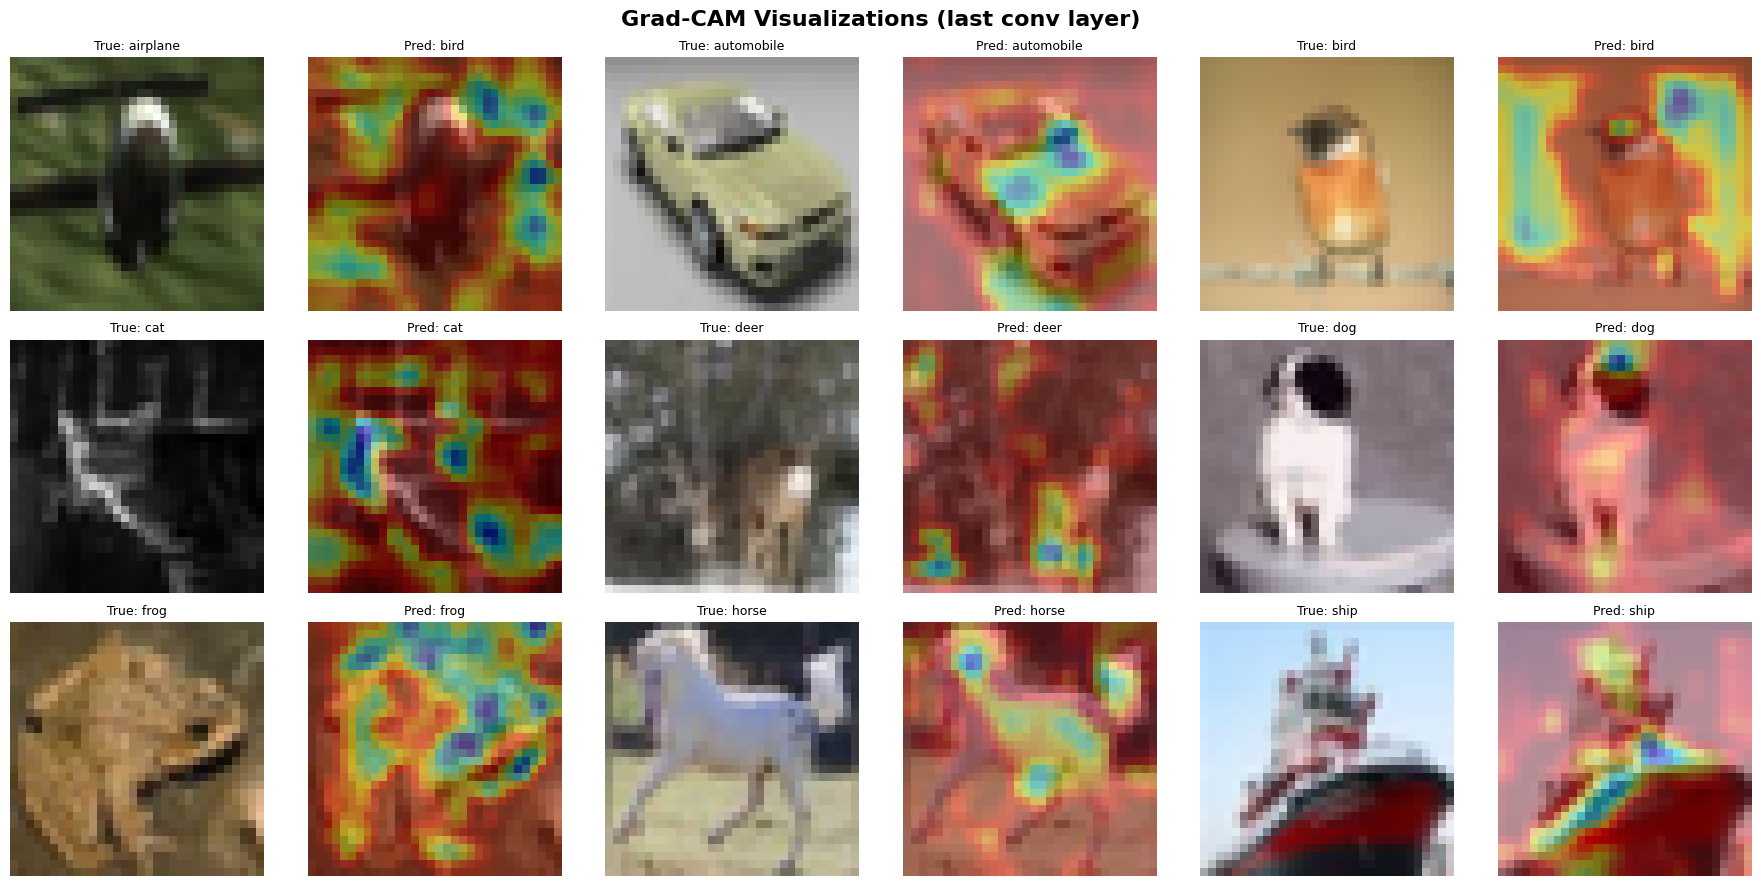

In [21]:
# ============================================================================
#  Grad‑CAM: Explain CNN Predictions
# ============================================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ---- Rebuild model_cnn as Functional (Keras 3 compat) ----
inp = Input(shape=(32, 32, 3))
x = inp
last_conv_layer = None
for layer in model_cnn.layers:
    x = layer(x)
    if 'conv2d' in layer.name:
        last_conv_layer = layer
        last_conv_output = x

# Two‑output model: conv feature maps + final predictions
grad_model = Model(inputs=inp, outputs=[last_conv_output, x])

def make_gradcam_heatmap(img_array, model, pred_index=None):
    """Compute Grad‑CAM heatmap for a single image."""
    with tf.GradientTape() as tape:
        conv_outputs, predictions = model(img_array, training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.4):
    """Overlay heatmap on image."""
    import cv2
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color   = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color   = heatmap_color.astype('float32') / 255.0
    superimposed    = heatmap_color * alpha + img * (1 - alpha)
    return np.clip(superimposed, 0, 1)

# ---- Visualize Grad‑CAM for several test images ----
y_test_labels = np.argmax(y_test_dl, axis=1)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Grad‑CAM Visualizations (last conv layer)', fontsize=16, fontweight='bold')

for row in range(3):
    for col_pair in range(3):
        cls_idx = row * 3 + col_pair
        idx = np.where(y_test_labels == cls_idx)[0][0]
        img = X_test_dl[idx]

        heatmap = make_gradcam_heatmap(img[np.newaxis], grad_model)
        cam_img = overlay_gradcam(img, heatmap)

        pred = np.argmax(model_cnn.predict(img[np.newaxis], verbose=0))

        # Original
        axes[row, col_pair * 2].imshow(img)
        axes[row, col_pair * 2].set_title(f'True: {class_names[cls_idx]}', fontsize=9)
        axes[row, col_pair * 2].axis('off')
        # Grad‑CAM
        axes[row, col_pair * 2 + 1].imshow(cam_img)
        axes[row, col_pair * 2 + 1].set_title(f'Pred: {class_names[pred]}', fontsize=9)
        axes[row, col_pair * 2 + 1].axis('off')

plt.tight_layout()
plt.show()


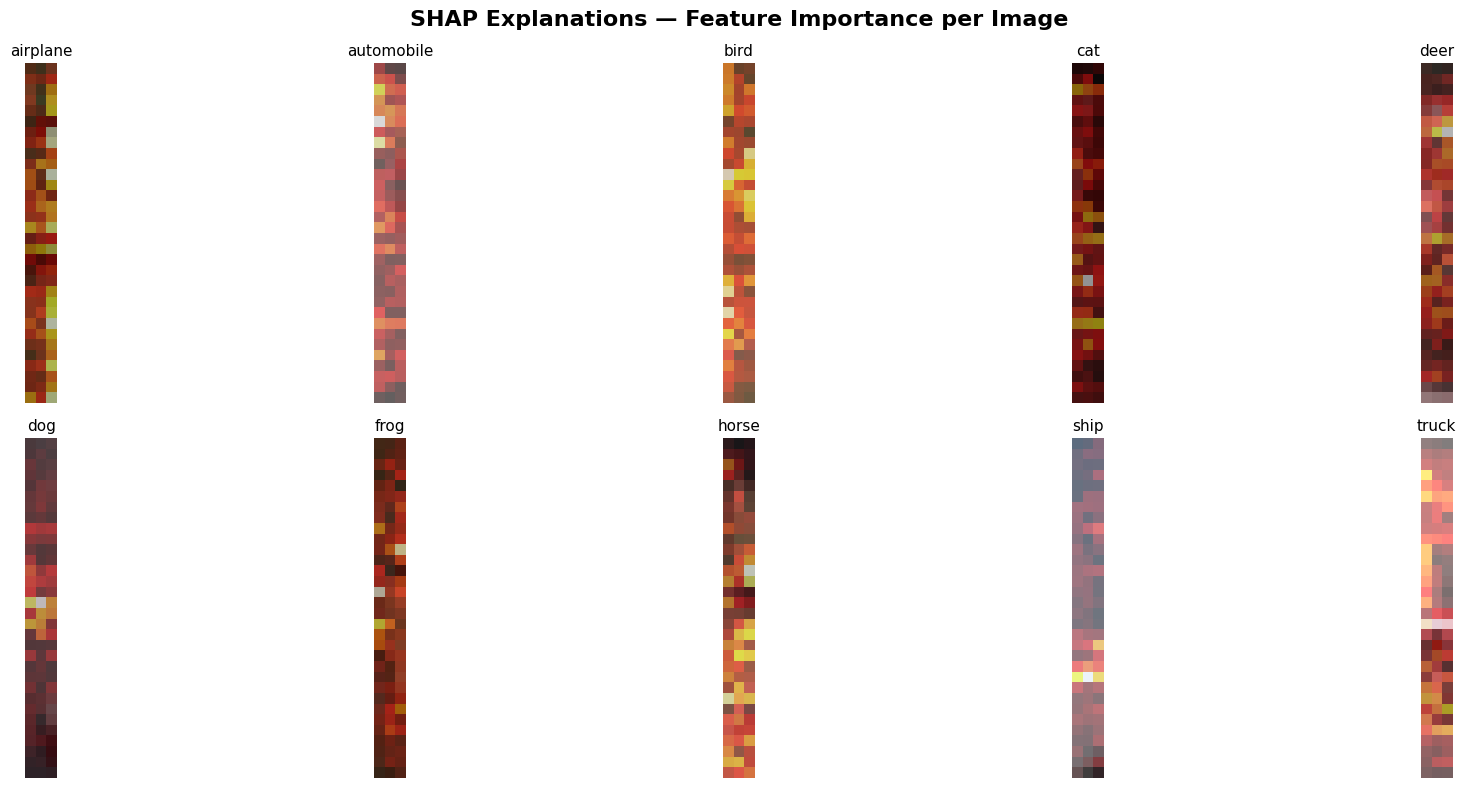

SHAP explanation complete!


In [22]:
# ============================================================================
#  SHAP: Explain Model Predictions
# ============================================================================

# Install shap if needed: !pip install shap
import shap
import numpy as np
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ---- Use a small background set for SHAP ----
background = X_train_dl[np.random.choice(X_train_dl.shape[0], 100, replace=False)]

# ---- Create SHAP explainer ----
explainer = shap.GradientExplainer(model_cnn, background)

# ---- Select test samples (one per class) ----
y_test_labels = np.argmax(y_test_dl, axis=1)
sample_images = []
sample_labels = []
for cls in range(10):
    idx = np.where(y_test_labels == cls)[0][0]
    sample_images.append(X_test_dl[idx])
    sample_labels.append(cls)

sample_images = np.array(sample_images)

# ---- Compute SHAP values ----
shap_values = explainer.shap_values(sample_images)

# ---- Plot SHAP image explanations ----
# shap_values is a list of 10 arrays (one per class)
# For each sample, show SHAP for its true class
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('SHAP Explanations — Feature Importance per Image',
             fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    ax  = axes[row, col]
    # Get SHAP values for the true class
    sv = shap_values[sample_labels[i]][i]
    # Average across color channels for visualization
    sv_mean = np.mean(np.abs(sv), axis=-1)
    ax.imshow(sample_images[i])
    ax.imshow(sv_mean, cmap='hot', alpha=0.5)
    ax.set_title(f'{class_names[sample_labels[i]]}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("SHAP explanation complete!")

PHASE 3 — MODEL COMPARISON SUMMARY
Model              Test Loss   Test Accuracy
-------------------------------------------------------
SimpleRNN             0.2297          0.9351
GRU                   0.3091          0.8877
LSTM                  0.1959          0.9405
ViT                   1.0606          0.7672


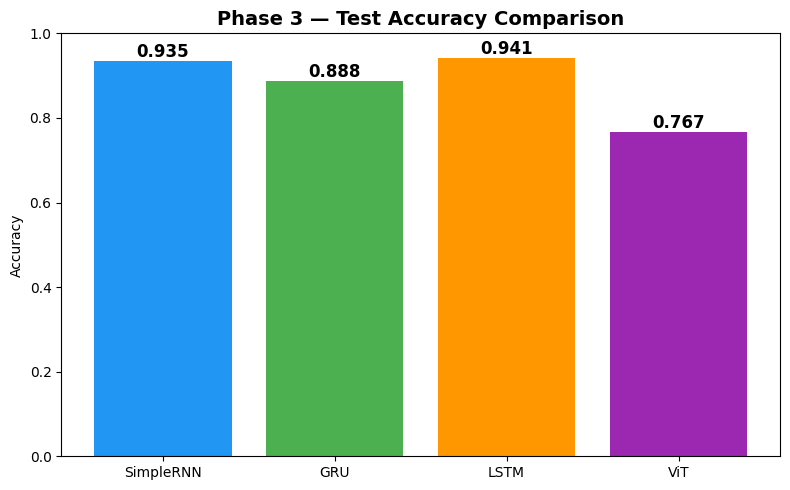


Phase 3 complete!


In [23]:
# ============================================================================
#  Comparative Summary of All Phase 3 Models
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Gather results
models_info = {
    'SimpleRNN': model_rnn.evaluate(X_test_seq, y_test_cat, verbose=0),
    'GRU':       model_gru.evaluate(X_test_seq, y_test_cat, verbose=0),
    'LSTM':      model_lstm.evaluate(X_test_seq, y_test_cat, verbose=0),
    'ViT':       model_vit.evaluate(X_test_full, y_test_oh,  verbose=0),
}

print("=" * 55)
print("PHASE 3 — MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<15} {'Test Loss':>12} {'Test Accuracy':>15}")
print("-" * 55)
for name, (loss, acc) in models_info.items():
    print(f"{name:<15} {loss:>12.4f} {acc:>15.4f}")
print("=" * 55)

# Bar chart
names = list(models_info.keys())
accs  = [v[1] for v in models_info.values()]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accs, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
plt.ylim(0, 1)
for bar, a in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{a:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.title('Phase 3 — Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

print("\nPhase 3 complete!")
